# Simulation and measurement comparison

This notebook compares Notebook 3's simulated AP effective-dose-rate field
with Notebook 5's theory-assisted measured AP field at the P1--P5 scan
positions. Notebook 3 is evaluated on Notebook 5's common target grid by
log-linear interpolation along the same position and exact target-height
curve. No simulated field is extrapolated beyond its distance support.

For each component,

$$
R_j(P,d,h)=
\frac{\dot E_{\mathrm{AP},j}^{(N3)}(P,d,h)}
     {\widehat{\dot E}_{\mathrm{AP},j}^{(N5)}(P,d,h)},
\qquad j\in\{n,\gamma,\mathrm{tot}\}.
$$

The simulated curves retain their OpenMC batch-statistical $\pm1\sigma$
bands. Notebook 5 values are shown as points with propagated $\pm1$ standard
uncertainty; zero-compatible points are displayed as open one-sided 95% upper
estimates instead of error bars clipped across zero on a logarithmic axis.

Notebook 5 uses Notebook 3's component-specific spectral conversion fields.
The total-field comparison is therefore a **model-assisted consistency test**,
not an independent validation and not a basis for an independence-assuming
$z$ score. The neutron and gamma components remain visible so compensating
component differences cannot be hidden by the total.


# 1) Setup and analysis conventions

The visual language matches Notebooks 3--5: P1 blue, P2 orange, P3 green, P4
red, and P5 purple; lighter shades indicate greater target height; dose-rate
axes are semi-logarithmic; and the derived total component is hot pink.

The two inclusive height intervals are $38$--$65$ cm and $85$--$113$ cm.
Exact target heights are retained throughout the analysis.


In [1]:
# ============================================================
# 1) Setup and immutable comparison conventions
# ============================================================

from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, to_rgb
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

try:
    from IPython.display import display
except ImportError:
    def display(*objects):
        for object_to_display in objects:
            print(object_to_display)

BASE_DIR = Path.cwd().resolve()

OUTPUT_DIR = BASE_DIR / "N6_simulation_vs_measurement_outputs"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
METADATA_DIR = OUTPUT_DIR / "metadata"

for directory in (OUTPUT_DIR, TABLE_DIR, FIGURE_DIR, METADATA_DIR):
    directory.mkdir(parents=True, exist_ok=True)

POSITION_SEQUENCE = ["P1", "P2", "P3", "P4", "P5"]
POSITION_ORDER = {
    position: index
    for index, position in enumerate(POSITION_SEQUENCE, start=1)
}
POSITION_COLORS = {
    "P1": "tab:blue",
    "P2": "tab:orange",
    "P3": "tab:green",
    "P4": "tab:red",
    "P5": "tab:purple",
}
TOTAL_COLOR = "hotpink"

HEIGHT_INTERVAL_SEQUENCE = ["lower", "upper"]
HEIGHT_INTERVAL_ORDER = {"lower": 0, "upper": 1}
ANALYSIS_HEIGHT_INTERVALS_CM = {
    "lower": (38.0, 65.0),
    "upper": (85.0, 113.0),
}
ANALYSIS_HEIGHT_INTERVAL_LABELS = {
    "lower": "Lower height interval (38–65 cm)",
    "upper": "Upper height interval (85–113 cm)",
}
HEIGHT_INTERVAL_PLOT_SETTINGS = {
    "lower": {
        "linestyle": "-",
        "marker": "o",
        "label": ANALYSIS_HEIGHT_INTERVAL_LABELS["lower"],
    },
    "upper": {
        "linestyle": "--",
        "marker": "s",
        "label": ANALYSIS_HEIGHT_INTERVAL_LABELS["upper"],
    },
}

TARGET_KEY = ["position", "distance_cm", "height_cm"]
ONE_SIDED_95_Z = 1.6448536269514722
DEFAULT_POSITION_LIMIT_CM = 1.0
MATCH_ATOL_CM = 1.0e-9

FIGURE_SUPTITLE_FONTSIZE = 17
FIGURE_TITLE_FONTSIZE = 15
FIGURE_LABEL_FONTSIZE = 13
FIGURE_TICK_FONTSIZE = 11
FIGURE_LEGEND_FONTSIZE = 10.5
FIGURE_LEGEND_TITLE_FONTSIZE = 11.5

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 190)
pd.set_option("display.max_colwidth", 150)
plt.rcParams.update({
    "figure.dpi": 150,
    "axes.titlesize": FIGURE_TITLE_FONTSIZE,
    "axes.labelsize": FIGURE_LABEL_FONTSIZE,
    "xtick.labelsize": FIGURE_TICK_FONTSIZE,
    "ytick.labelsize": FIGURE_TICK_FONTSIZE,
    "legend.fontsize": FIGURE_LEGEND_FONTSIZE,
})

exported_figure_rows = []


def first_existing_project_file(candidates, label):
    for candidate in candidates:
        candidate = Path(candidate)
        if candidate.is_file():
            print(f"Using {label}: {candidate}")
            return candidate
    tried = "\n".join(f"  {Path(candidate)}" for candidate in candidates)
    raise FileNotFoundError(f"Could not find {label}. Tried:\n{tried}")


def require_columns(dataframe, columns, label):
    missing = [column for column in columns if column not in dataframe.columns]
    if missing:
        raise KeyError(
            f"{label} is missing required columns: {missing}. "
            f"Available columns: {dataframe.columns.tolist()}"
        )


def canonical_position(series):
    return series.astype(str).str.strip().str.upper()


def assign_analysis_height_interval(height_cm):
    height_cm = float(height_cm)
    for interval, (lower_cm, upper_cm) in ANALYSIS_HEIGHT_INTERVALS_CM.items():
        if lower_cm <= height_cm <= upper_cm:
            return interval
    return pd.NA


def lighten_color(color, amount):
    rgb = np.asarray(to_rgb(color), dtype=float)
    return tuple((1.0 - amount) * rgb + amount * np.ones(3))


def build_position_height_colors(dataframe):
    colors = {}
    for position in POSITION_SEQUENCE:
        heights = np.sort(
            dataframe.loc[dataframe["position"].eq(position), "height_cm"]
            .dropna().unique().astype(float)
        )
        if not len(heights):
            continue
        amounts = np.linspace(0.0, 0.58, len(heights))
        for height_cm, amount in zip(heights, amounts):
            colors[(position, float(height_cm))] = lighten_color(
                POSITION_COLORS[position], float(amount)
            )
    return colors


def save_figure(figure, filename_stem):
    png_path = FIGURE_DIR / f"{filename_stem}.png"
    pdf_path = FIGURE_DIR / f"{filename_stem}.pdf"
    figure.savefig(png_path, dpi=300, bbox_inches="tight")
    figure.savefig(pdf_path, bbox_inches="tight")
    exported_figure_rows.append({
        "stem": filename_stem,
        "png_path": str(png_path.resolve()),
        "pdf_path": str(pdf_path.resolve()),
    })


def show_save_close(figure, filename_stem):
    save_figure(figure, filename_stem)
    plt.show()
    plt.close(figure)


def plot_simulated_curve_with_band(
    axis, x, y, uncertainty, *, color, linestyle="-", linewidth=1.35,
    alpha=0.90, band_alpha=0.10, zorder=2,
):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    uncertainty = np.asarray(uncertainty, dtype=float)
    valid = np.isfinite(x) & np.isfinite(y) & (y > 0.0)
    plotted_y = np.where(valid, y, np.nan)
    axis.plot(
        x, plotted_y, color=color, linestyle=linestyle,
        linewidth=linewidth, alpha=alpha, zorder=zorder,
    )
    band_valid = (
        valid & np.isfinite(uncertainty) & (uncertainty >= 0.0)
        & ((y - uncertainty) > 0.0)
    )
    if np.any(band_valid):
        axis.fill_between(
            x, y - uncertainty, y + uncertainty,
            where=band_valid, interpolate=False,
            color=color, alpha=band_alpha, linewidth=0.0,
            zorder=zorder - 1,
        )


def plot_measured_points(
    axis, x, y, uncertainty, *, color, marker="o", connect=True,
    connect_linestyle="-", xerr=DEFAULT_POSITION_LIMIT_CM, zorder=4,
):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    uncertainty = np.asarray(uncertainty, dtype=float)
    valid = (
        np.isfinite(x) & np.isfinite(y) & (y > 0.0)
        & np.isfinite(uncertainty) & (uncertainty >= 0.0)
    )
    regular = valid & ((y - uncertainty) > 0.0)
    zero_compatible = valid & ~regular

    if connect:
        connected_y = np.where(regular, y, np.nan)
        axis.plot(
            x, connected_y, color=color, linestyle=connect_linestyle,
            linewidth=1.0, alpha=0.62, zorder=zorder - 1,
        )
    if np.any(regular):
        axis.errorbar(
            x[regular], y[regular],
            xerr=np.full(regular.sum(), float(xerr)),
            yerr=uncertainty[regular],
            fmt=marker, linestyle="none", color=color,
            markerfacecolor=color, markeredgecolor=color,
            markersize=5.4, ecolor=color, elinewidth=1.0,
            capsize=3, zorder=zorder,
        )
    if np.any(zero_compatible):
        upper_95 = y[zero_compatible] + ONE_SIDED_95_Z * uncertainty[zero_compatible]
        axis.errorbar(
            x[zero_compatible], upper_95,
            xerr=np.full(zero_compatible.sum(), float(xerr)),
            fmt="v", linestyle="none", color=color,
            markerfacecolor="none", markeredgecolor=color,
            markeredgewidth=1.25, markersize=6.2,
            ecolor=color, elinewidth=0.9, capsize=3, zorder=zorder,
        )
    return int(regular.sum()), int(zero_compatible.sum())


print("Notebook 6 setup completed.")
print(f"Working directory: {BASE_DIR}")
print(f"Output directory:  {OUTPUT_DIR}")


Notebook 6 setup completed.
Working directory: /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn
Output directory:  /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N6_simulation_vs_measurement_outputs


# 2) Load and validate the canonical Notebook 3 and Notebook 5 handoffs

Notebook 3 supplies the simulated neutron, gamma, and total AP components with
their OpenMC batch-statistical standard uncertainties. Notebook 5 supplies the
separately interpolated measured components and their theory-assisted sum on
the common target grid.

The obsolete matched-point table from the former Notebook 5 is not used.


In [2]:
# ============================================================
# 2) Load and audit the two canonical comparison inputs
# ============================================================

n3_input_path = first_existing_project_file(
    [
        BASE_DIR / "N3_simulated_unified_outputs" / "tables"
        / "unified_simulated_radiation_field_final.csv",
        BASE_DIR / "unified_simulated_radiation_field_final.csv",
    ],
    "Notebook 3 unified simulated AP field",
)
n5_input_path = first_existing_project_file(
    [
        BASE_DIR / "N5_unified_measured_outputs" / "tables"
        / "measured_total_ap_field_common_grid_final.csv",
    ],
    "Notebook 5 theory-assisted measured AP field",
)

n3_raw_df = pd.read_csv(n3_input_path)
n5_raw_df = pd.read_csv(n5_input_path)

require_columns(
    n3_raw_df,
    [
        "point_name", "position", "distance_cm", "height_cm",
        "common_dose_x_cm", "common_dose_y_cm", "common_dose_z_cm",
        "neutron_dose_rate [uSv/h]",
        "u_mc_neutron_dose_rate [uSv/h]",
        "gamma_dose_rate [uSv/h]",
        "u_mc_gamma_dose_rate [uSv/h]",
        "total_dose_rate [uSv/h]",
        "u_mc_total_dose_rate [uSv/h]",
    ],
    "Notebook 3 input",
)
require_columns(
    n5_raw_df,
    [
        "point_name", "position", "distance_cm", "height_cm",
        "common_dose_x_cm", "common_dose_y_cm", "common_dose_z_cm",
        "analysis_height_interval", "analysis_height_interval_label",
        "measured_neutron_ap_component_uSv_h",
        "u_measured_neutron_ap_component_uSv_h",
        "measured_gamma_ap_component_uSv_h",
        "u_measured_gamma_ap_component_uSv_h",
        "measured_total_ap_estimate_uSv_h",
        "u_measured_total_ap_estimate_uSv_h",
        "neutron_component_available", "gamma_component_available",
        "total_estimate_available", "horizontal_position_limit_cm",
    ],
    "Notebook 5 input",
)

n3_df = n3_raw_df.rename(columns={
    "neutron_dose_rate [uSv/h]": "simulated_neutron_ap_uSv_h",
    "u_mc_neutron_dose_rate [uSv/h]": "u_mc_simulated_neutron_ap_uSv_h",
    "gamma_dose_rate [uSv/h]": "simulated_gamma_ap_uSv_h",
    "u_mc_gamma_dose_rate [uSv/h]": "u_mc_simulated_gamma_ap_uSv_h",
    "total_dose_rate [uSv/h]": "simulated_total_ap_uSv_h",
    "u_mc_total_dose_rate [uSv/h]": "u_mc_simulated_total_ap_uSv_h",
}).copy()
n5_df = n5_raw_df.copy()

for dataframe in (n3_df, n5_df):
    dataframe["position"] = canonical_position(dataframe["position"])
    for column in [
        "distance_cm", "height_cm", "common_dose_x_cm",
        "common_dose_y_cm", "common_dose_z_cm",
    ]:
        dataframe[column] = pd.to_numeric(dataframe[column], errors="coerce")

for column in [
    "simulated_neutron_ap_uSv_h", "u_mc_simulated_neutron_ap_uSv_h",
    "simulated_gamma_ap_uSv_h", "u_mc_simulated_gamma_ap_uSv_h",
    "simulated_total_ap_uSv_h", "u_mc_simulated_total_ap_uSv_h",
]:
    n3_df[column] = pd.to_numeric(n3_df[column], errors="coerce")

for column in [
    "measured_neutron_ap_component_uSv_h",
    "u_measured_neutron_ap_component_uSv_h",
    "measured_gamma_ap_component_uSv_h",
    "u_measured_gamma_ap_component_uSv_h",
    "measured_total_ap_estimate_uSv_h",
    "u_measured_total_ap_estimate_uSv_h",
    "horizontal_position_limit_cm",
]:
    n5_df[column] = pd.to_numeric(n5_df[column], errors="coerce")

for column in [
    "neutron_component_available", "gamma_component_available",
    "total_estimate_available",
]:
    if n5_df[column].dtype != bool:
        n5_df[column] = (
            n5_df[column].astype(str).str.strip().str.lower().eq("true")
        )

n3_df["analysis_height_interval"] = n3_df["height_cm"].apply(
    assign_analysis_height_interval
)
n3_df["analysis_height_interval_label"] = n3_df[
    "analysis_height_interval"
].map(ANALYSIS_HEIGHT_INTERVAL_LABELS)

n3_df = n3_df.loc[n3_df["position"].isin(POSITION_SEQUENCE)].copy()
n5_df = n5_df.loc[n5_df["position"].isin(POSITION_SEQUENCE)].copy()

if n3_df.duplicated(TARGET_KEY).any():
    raise ValueError("Notebook 3 contains duplicate nominal target points.")
if n5_df.duplicated(TARGET_KEY).any():
    raise ValueError("Notebook 5 contains duplicate common-grid target points.")

input_audit_df = pd.DataFrame([
    {
        "input_role": "Notebook 3 simulated physical AP field",
        "path": str(n3_input_path.resolve()),
        "rows": len(n3_df),
        "columns": len(n3_df.columns),
    },
    {
        "input_role": "Notebook 5 theory-assisted measured AP field",
        "path": str(n5_input_path.resolve()),
        "rows": len(n5_df),
        "columns": len(n5_df.columns),
    },
])

print("Canonical inputs loaded and validated.")
display(input_audit_df)


Using Notebook 3 unified simulated AP field: /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N3_simulated_unified_outputs/tables/unified_simulated_radiation_field_final.csv
Using Notebook 5 theory-assisted measured AP field: /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N5_unified_measured_outputs/tables/measured_total_ap_field_common_grid_final.csv
Canonical inputs loaded and validated.


,input_role,path,rows,columns
0,Notebook 3 simulated physical AP field,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N3_simulated_unified_outputs/tables/unified_simulated_radiation_field_final.csv,61,74
1,Notebook 5 theory-assisted measured AP field,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N5_unified_measured_outputs/tables/measured_total_ap_field_common_grid_final.csv,81,33


# 3) Evaluate Notebook 3 on Notebook 5's common target grid

Notebook 5 contains every measurement-supported distance at Notebook 3's exact
target heights. For each $(P,h)$ curve, Notebook 3 is therefore evaluated at
the Notebook 5 distance by positive log-linear interpolation,

$$
\ln \dot E(d)=
\operatorname{interp}\!\left(d;\,d_i,\ln \dot E_i\right).
$$

Exact Notebook 3 nodes are preserved. Points outside the simulated distance
support, or without the same P-position and target height, remain unavailable;
nearest-position substitution and extrapolation are prohibited.


In [3]:
# ============================================================
# 3) Common comparison grid and simulated-field interpolation
# ============================================================

SIMULATED_VALUE_COLUMNS = [
    "simulated_neutron_ap_uSv_h",
    "u_mc_simulated_neutron_ap_uSv_h",
    "simulated_gamma_ap_uSv_h",
    "u_mc_simulated_gamma_ap_uSv_h",
    "simulated_total_ap_uSv_h",
    "u_mc_simulated_total_ap_uSv_h",
]


def positive_log_interpolate(target, xp, fp):
    xp = np.asarray(xp, dtype=float)
    fp = np.asarray(fp, dtype=float)
    valid = np.isfinite(xp) & np.isfinite(fp) & (fp > 0.0)
    xp = xp[valid]
    fp = fp[valid]
    if xp.size == 0:
        return np.nan
    order = np.argsort(xp)
    xp = xp[order]
    fp = fp[order]
    if target < xp[0] - MATCH_ATOL_CM or target > xp[-1] + MATCH_ATOL_CM:
        return np.nan
    exact = np.isclose(xp, target, rtol=0.0, atol=MATCH_ATOL_CM)
    if exact.any():
        return float(fp[np.flatnonzero(exact)[0]])
    if xp.size < 2:
        return np.nan
    return float(np.exp(np.interp(float(target), xp, np.log(fp))))


comparison_rows = []
for target in n5_df.itertuples(index=False):
    same_curve = n3_df.loc[
        n3_df["position"].eq(target.position)
        & np.isclose(
            n3_df["height_cm"].to_numpy(float),
            float(target.height_cm),
            rtol=0.0,
            atol=MATCH_ATOL_CM,
        )
    ].sort_values("distance_cm")

    if same_curve.empty:
        interpolation_status = "no identical P-position and target-height curve"
        simulated_values = {column: np.nan for column in SIMULATED_VALUE_COLUMNS}
    else:
        minimum_distance = float(same_curve["distance_cm"].min())
        maximum_distance = float(same_curve["distance_cm"].max())
        if not (
            minimum_distance - MATCH_ATOL_CM
            <= float(target.distance_cm)
            <= maximum_distance + MATCH_ATOL_CM
        ):
            interpolation_status = "outside Notebook 3 distance support"
            simulated_values = {
                column: np.nan for column in SIMULATED_VALUE_COLUMNS
            }
        else:
            exact = np.isclose(
                same_curve["distance_cm"].to_numpy(float),
                float(target.distance_cm),
                rtol=0.0,
                atol=MATCH_ATOL_CM,
            )
            interpolation_status = (
                "exact Notebook 3 target point"
                if exact.any()
                else "log-linear interpolation within identical P and height"
            )
            simulated_values = {
                column: positive_log_interpolate(
                    float(target.distance_cm),
                    same_curve["distance_cm"],
                    same_curve[column],
                )
                for column in SIMULATED_VALUE_COLUMNS
            }

    comparison_rows.append({
        **target._asdict(),
        **simulated_values,
        "simulation_grid_status": interpolation_status,
    })

comparison_df = pd.DataFrame(comparison_rows)

comparison_df["simulation_available"] = (
    np.isfinite(comparison_df["simulated_total_ap_uSv_h"])
    & (comparison_df["simulated_total_ap_uSv_h"] > 0.0)
    & np.isfinite(comparison_df["u_mc_simulated_total_ap_uSv_h"])
)
comparison_df["neutron_comparison_available"] = (
    comparison_df["simulation_available"]
    & comparison_df["neutron_component_available"]
    & np.isfinite(comparison_df["measured_neutron_ap_component_uSv_h"])
    & (comparison_df["measured_neutron_ap_component_uSv_h"] > 0.0)
)
comparison_df["gamma_comparison_available"] = (
    comparison_df["simulation_available"]
    & comparison_df["gamma_component_available"]
    & np.isfinite(comparison_df["measured_gamma_ap_component_uSv_h"])
    & (comparison_df["measured_gamma_ap_component_uSv_h"] > 0.0)
)
comparison_df["total_comparison_available"] = (
    comparison_df["simulation_available"]
    & comparison_df["total_estimate_available"]
    & np.isfinite(comparison_df["measured_total_ap_estimate_uSv_h"])
    & (comparison_df["measured_total_ap_estimate_uSv_h"] > 0.0)
)

component_definitions = {
    "neutron": {
        "simulated": "simulated_neutron_ap_uSv_h",
        "measured": "measured_neutron_ap_component_uSv_h",
        "available": "neutron_comparison_available",
    },
    "gamma": {
        "simulated": "simulated_gamma_ap_uSv_h",
        "measured": "measured_gamma_ap_component_uSv_h",
        "available": "gamma_comparison_available",
    },
    "total": {
        "simulated": "simulated_total_ap_uSv_h",
        "measured": "measured_total_ap_estimate_uSv_h",
        "available": "total_comparison_available",
    },
}

for component, columns in component_definitions.items():
    available = comparison_df[columns["available"]]
    simulated = comparison_df[columns["simulated"]]
    measured = comparison_df[columns["measured"]]
    ratio = np.where(available, simulated / measured, np.nan)
    comparison_df[f"simulated_to_n5_{component}_ratio"] = ratio
    comparison_df[f"log10_simulated_to_n5_{component}_ratio"] = np.where(
        np.isfinite(ratio) & (ratio > 0.0), np.log10(ratio), np.nan
    )
    comparison_df[
        f"simulated_minus_n5_{component}_relative_residual_percent"
    ] = np.where(
        available,
        100.0 * (simulated - measured) / measured,
        np.nan,
    )
    comparison_df[
        f"n5_minus_simulated_{component}_relative_deviation_percent"
    ] = np.where(
        available,
        100.0 * (measured - simulated) / simulated,
        np.nan,
    )

comparison_df["comparison_dependence_status"] = (
    "Notebook 5 uses Notebook 3 component conversion fields; "
    "central ratios are descriptive and total comparison is not independent"
)
comparison_df["ratio_uncertainty_status"] = (
    "not propagated as independent; covariance is unavailable"
)

comparison_df["_position_order"] = comparison_df["position"].map(POSITION_ORDER)
comparison_df["_interval_order"] = comparison_df[
    "analysis_height_interval"
].map(HEIGHT_INTERVAL_ORDER)
comparison_df = (
    comparison_df
    .sort_values([
        "_position_order", "_interval_order", "height_cm", "distance_cm"
    ])
    .drop(columns=["_position_order", "_interval_order"])
    .reset_index(drop=True)
)

if comparison_df.duplicated(TARGET_KEY).any():
    raise RuntimeError("The final comparison grid contains duplicate keys.")

position_height_colors = build_position_height_colors(comparison_df)

print("Notebook 3 evaluated on Notebook 5's common target grid.")
print(f"Comparison-grid rows: {len(comparison_df)}")
print(
    "Total comparisons available: "
    f"{int(comparison_df['total_comparison_available'].sum())}"
)
display(comparison_df.head(12))


Notebook 3 evaluated on Notebook 5's common target grid.
Comparison-grid rows: 81
Total comparisons available: 37


,point_name,position,distance_cm,height_cm,common_dose_x_cm,common_dose_y_cm,common_dose_z_cm,gamma_flux_x_cm,gamma_flux_y_cm,gamma_flux_z_cm,analysis_height_interval,analysis_height_interval_label,target_grid_origin,geometry_reconstruction_mode,measured_neutron_ap_component_uSv_h,u_measured_neutron_ap_component_uSv_h,measured_gamma_ap_component_uSv_h,u_measured_gamma_ap_component_uSv_h,measured_total_ap_estimate_uSv_h,u_measured_total_ap_estimate_uSv_h,neutron_component_available,gamma_component_available,total_estimate_available,neutron_height_interpolation_mode,gamma_height_interpolation_mode,neutron_support_minimum_height_cm,neutron_support_maximum_height_cm,gamma_support_minimum_height_cm,gamma_support_maximum_height_cm,horizontal_position_limit_cm,vertical_uncertainty_scope,result_status,relative_total_uncertainty_percent,simulated_neutron_ap_uSv_h,u_mc_simulated_neutron_ap_uSv_h,simulated_gamma_ap_uSv_h,u_mc_simulated_gamma_ap_uSv_h,simulated_total_ap_uSv_h,u_mc_simulated_total_ap_uSv_h,simulation_grid_status,simulation_available,neutron_comparison_available,gamma_comparison_available,total_comparison_available,simulated_to_n5_neutron_ratio,log10_simulated_to_n5_neutron_ratio,simulated_minus_n5_neutron_relative_residual_percent,n5_minus_simulated_neutron_relative_deviation_percent,simulated_to_n5_gamma_ratio,log10_simulated_to_n5_gamma_ratio,simulated_minus_n5_gamma_relative_residual_percent,n5_minus_simulated_gamma_relative_deviation_percent,simulated_to_n5_total_ratio,log10_simulated_to_n5_total_ratio,simulated_minus_n5_total_relative_residual_percent,n5_minus_simulated_total_relative_deviation_percent,comparison_dependence_status,ratio_uncertainty_status
0,P1_x0_h42,P1,0.0,42.0,0.0,-44.25,1.0,0.0,-35.405,1.0,lower,Lower height interval (38–65 cm),Notebook 3 target point,original Notebook 3 geometry,541.600000,25.412725,NaN,NaN,NaN,NaN,True,False,False,single measured height represents interval,unavailable,42.0,42.0,NaN,NaN,1.0,measurement SEM plus Notebook 3 MC factor uncertainty; component statistics combined as independent,theory-assisted AP component sum; not an independent direct total measurement,NaN,121.499498,3.986762,0.959521,0.066381,122.459019,3.987315,exact Notebook 3 target point,True,True,False,False,0.224334,-0.649104,-77.566562,345.763160,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Notebook 5 uses Notebook 3 component conversion fields; central ratios are descriptive and total comparison is not independent,not propagated as independent; covariance is unavailable
1,P1_x4_h42,P1,4.0,42.0,0.0,-48.25,1.0,0.0,-39.405,1.0,lower,Lower height interval (38–65 cm),Notebook 3 target point,original Notebook 3 geometry,470.483333,22.373505,NaN,NaN,NaN,NaN,True,False,False,single measured height represents interval,unavailable,42.0,42.0,NaN,NaN,1.0,measurement SEM plus Notebook 3 MC factor uncertainty; component statistics combined as independent,theory-assisted AP component sum; not an independent direct total measurement,NaN,104.259807,3.461812,0.774171,0.058001,105.033978,3.462298,exact Notebook 3 target point,True,True,False,False,0.221601,-0.654427,-77.839851,351.260506,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Notebook 5 uses Notebook 3 component conversion fields; central ratios are descriptive and total comparison is not independent,not propagated as independent; covariance is unavailable
2,N5_P1_x6_h42,P1,6.0,42.0,0.0,-50.25,1.0,0.0,-41.405,1.0,lower,Lower height interval (38–65 cm),measured distance added to Notebook 3 target height,position-specific least-squares Notebook 3 coordinate plane,441.303999,21.795868,43.343185,3.818087,484.647184,22.127757,True,True,True,single measured height represents interval,single measured height represents interval,42.0,42.0,50.0,50.0,1.0,measurement SEM plus Notebook 3 MC factor uncertainty; component statistics combined as independent,theory-assisted AP component sum; not an independent direct total measurement,4.565746,97.743619,3.370354,0.730246,0.056091,98.474230,3.370822,log-linear inte

# 4) Coverage and comparison audit

The audit separates exact Notebook 3 nodes from distance-interpolated nodes and
reports unsupported points explicitly. A row enters a component comparison
only when both Notebook 3 and Notebook 5 contain a positive finite value for
that component.


In [4]:
# ============================================================
# 4) Coverage, interpolation, and method audit
# ============================================================

coverage_summary_df = (
    comparison_df
    .groupby(
        ["position", "analysis_height_interval", "analysis_height_interval_label"],
        dropna=False,
    )
    .agg(
        comparison_grid_points=("point_name", "size"),
        exact_notebook3_points=(
            "simulation_grid_status",
            lambda series: int(series.eq("exact Notebook 3 target point").sum()),
        ),
        interpolated_notebook3_points=(
            "simulation_grid_status",
            lambda series: int(series.str.startswith("log-linear").sum()),
        ),
        simulation_available_points=("simulation_available", "sum"),
        neutron_comparisons=("neutron_comparison_available", "sum"),
        gamma_comparisons=("gamma_comparison_available", "sum"),
        total_comparisons=("total_comparison_available", "sum"),
        target_heights_cm=(
            "height_cm",
            lambda series: ", ".join(
                f"{value:g}" for value in np.sort(series.unique())
            ),
        ),
        minimum_distance_cm=("distance_cm", "min"),
        maximum_distance_cm=("distance_cm", "max"),
    )
    .reset_index()
)

methodology_audit_df = pd.DataFrame([
    {
        "item": "comparison support",
        "method": "same P-position, exact target height, and in-support distance",
        "interpretation": "no nearest-P substitution and no extrapolation",
    },
    {
        "item": "Notebook 3 display uncertainty",
        "method": "OpenMC batch-statistical ±1 standard uncertainty band",
        "interpretation": "simulation sampling precision only",
    },
    {
        "item": "Notebook 5 display uncertainty",
        "method": "propagated ±1 standard uncertainty bars",
        "interpretation": "measurement SEM plus Notebook 3 factor MC term",
    },
    {
        "item": "zero-compatible Notebook 5 point",
        "method": "open downward triangle at one-sided 95% upper estimate",
        "interpretation": "avoids artificial log-axis clipping across zero",
    },
    {
        "item": "ratio and relative deviation",
        "method": "central values only",
        "interpretation": "descriptive because cross-covariance is unavailable",
    },
    {
        "item": "total comparison",
        "method": "Notebook 3 physical total vs Notebook 5 theory-assisted total",
        "interpretation": "model-assisted consistency test, not independent validation",
    },
])

display(coverage_summary_df)
display(methodology_audit_df)


,position,analysis_height_interval,analysis_height_interval_label,comparison_grid_points,exact_notebook3_points,interpolated_notebook3_points,simulation_available_points,neutron_comparisons,gamma_comparisons,total_comparisons,target_heights_cm,minimum_distance_cm,maximum_distance_cm
0,P1,lower,Lower height interval (38–65 cm),20,8,12,20,20,17,17,42,0.0,420.0
1,P1,upper,Upper height interval (85–113 cm),9,9,0,9,9,0,0,85,0.0,420.0
2,P2,lower,Lower height interval (38–65 cm),7,7,0,7,7,6,6,55,2.0,420.0
3,P2,upper,Upper height interval (85–113 cm),12,10,1,11,11,3,3,85,0.0,400.0
4,P3,lower,Lower height interval (38–65 cm),9,8,0,8,8,4,4,45,0.0,320.0
5,P3,upper,Upper height interval (85–113 cm),10,10,0,10,10,1,1,85,0.0,400.0
6,P4,lower,Lower height interval (38–65 cm),8,4,0,4,4,3,3,"42, 45",0.0,85.0
7,P4,upper,Upper height interval (85–113 cm),2,1,0,1,1,0,0,113,138.0,152.0
8,P5,lower,Lower height interval (38–65 cm),2,2,0,2,2,2,2,45,0.0,6.0
9,P5,upper,Upper height interval (85–113 cm),2,2,0,2,2,1,1,85,0.0,6.0


,item,method,interpretation
0,comparison support,"same P-position, exact target height, and in-support distance",no nearest-P substitution and no extrapolation
1,Notebook 3 display uncertainty,OpenMC batch-statistical ±1 standard uncertainty band,simulation sampling precision only
2,Notebook 5 display uncertainty,propagated ±1 standard uncertainty bars,measurement SEM plus Notebook 3 factor MC term
3,zero-compatible Notebook 5 point,open downward triangle at one-sided 95% upper estimate,avoids artificial log-axis clipping across zero
4,ratio and relative deviation,central values only,descriptive because cross-covariance is unavailable
5,total comparison,Notebook 3 physical total vs Notebook 5 theory-assisted total,"model-assisted consistency test, not independent validation"


# 5) Simulated and Notebook 5 total fields on the same axes

The following report figures place both total-field values on identical axes:

1. all lower- and upper-height target groups;
2. lower-height targets only;
3. upper-height targets only.

The common comparison groups are lower ($38$--$65$ cm) and upper
($85$--$113$ cm). Individual target heights remain separate internally so
measurements at different physical heights are never joined into an artificial
zigzag curve. Colour identifies P1--P5, while solid circles identify the lower
group and dashed squares identify the upper group.

Lines and bands belong to Notebook 3. Connected markers and vertical bars
belong to Notebook 5. Notebook 5 markers are connected only within the same
P-position, common height interval, and actual target height. Their different
uncertainty glyphs are intentional because the uncertainty sources are
different.


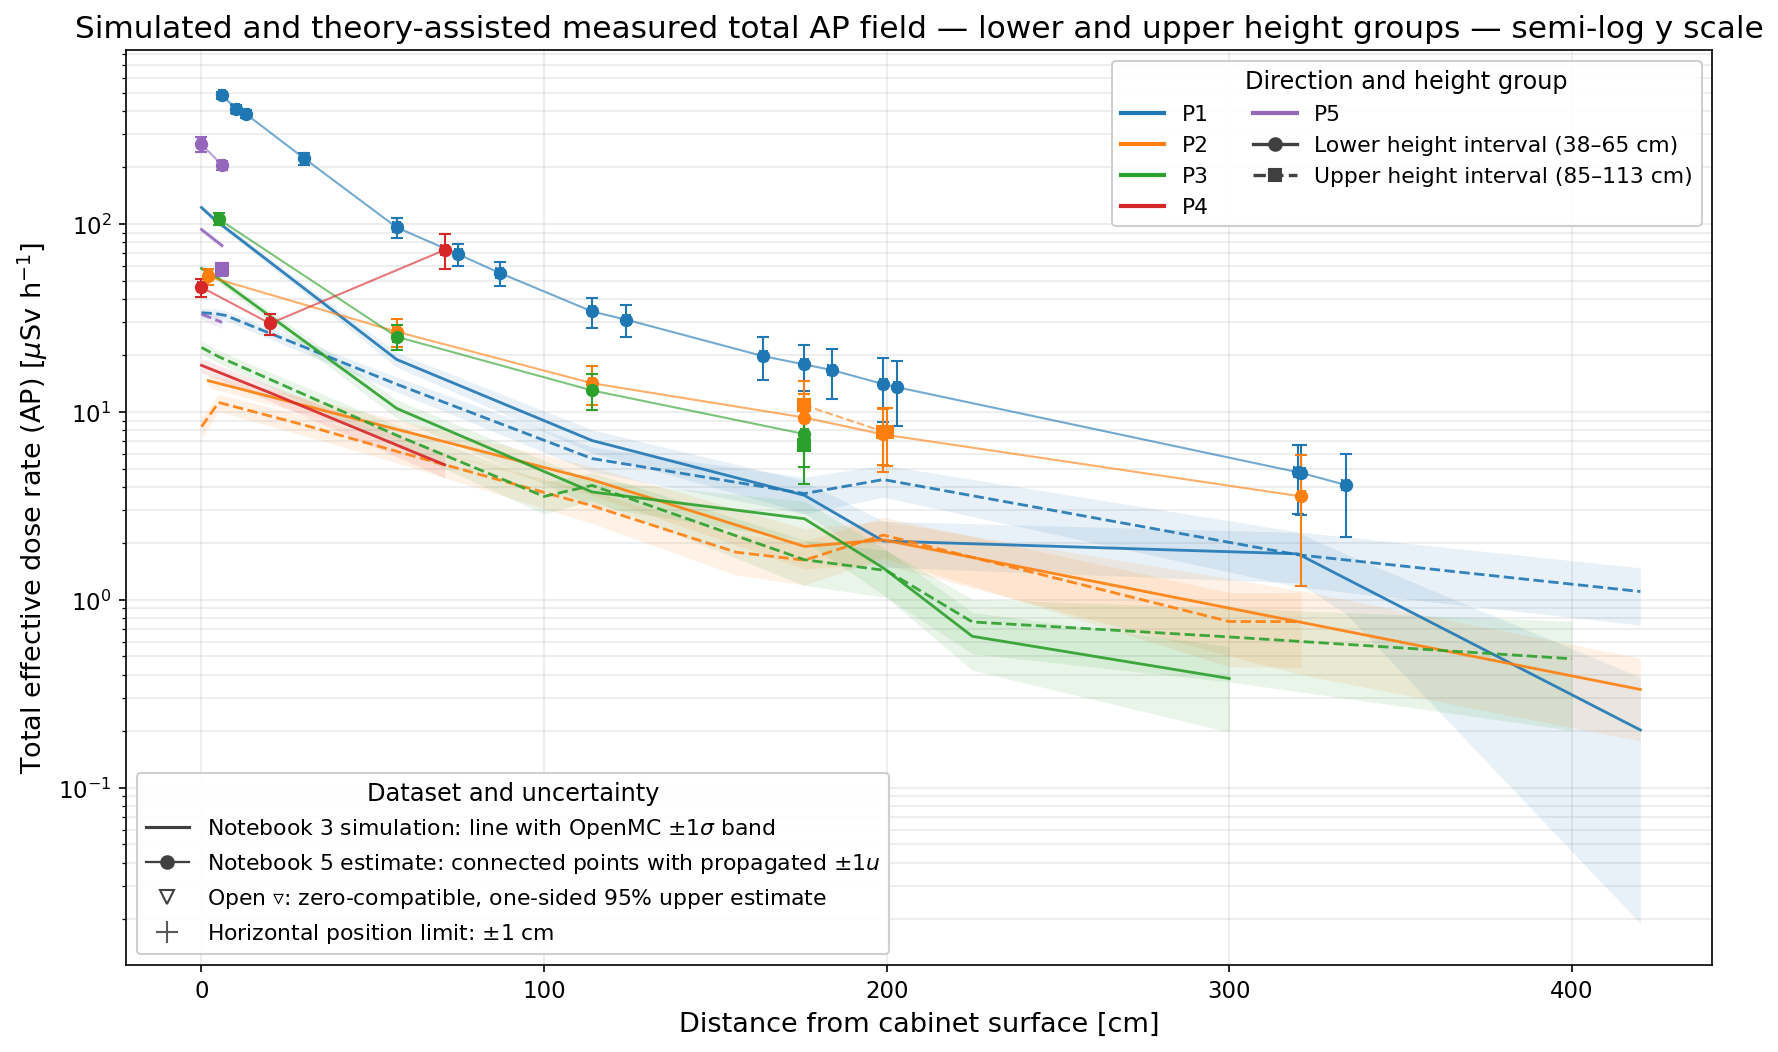

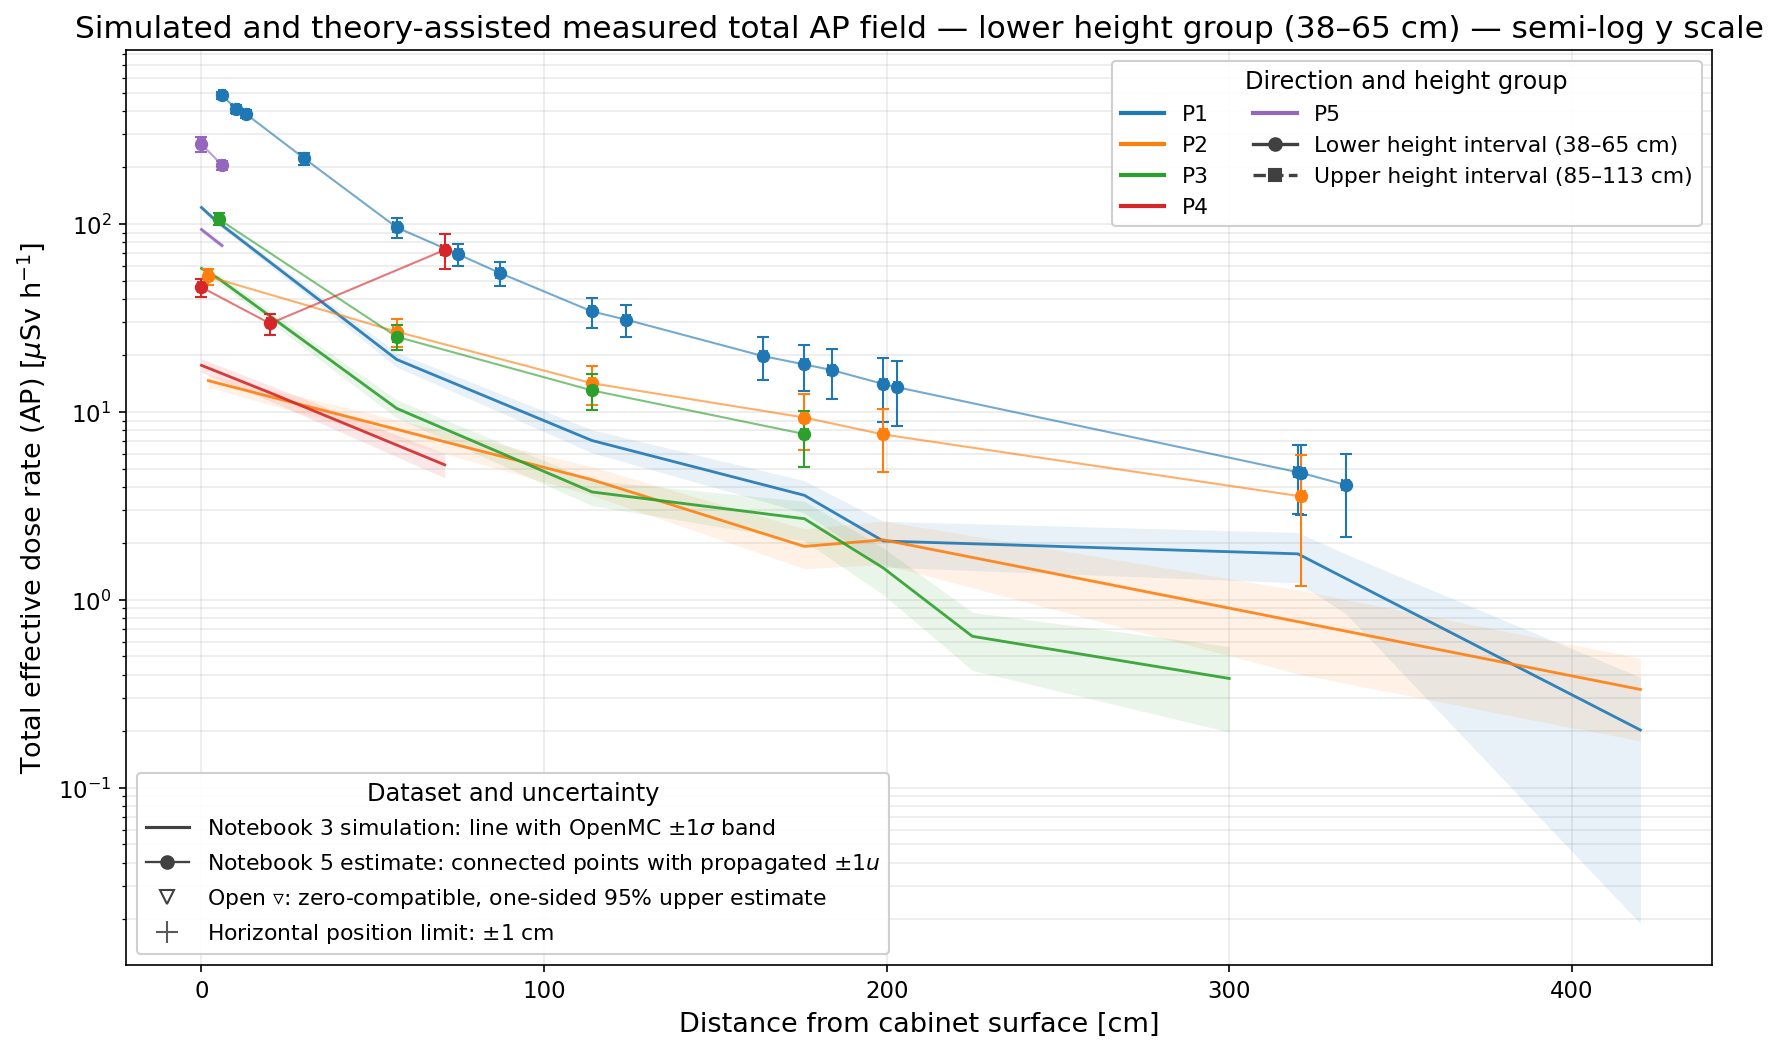

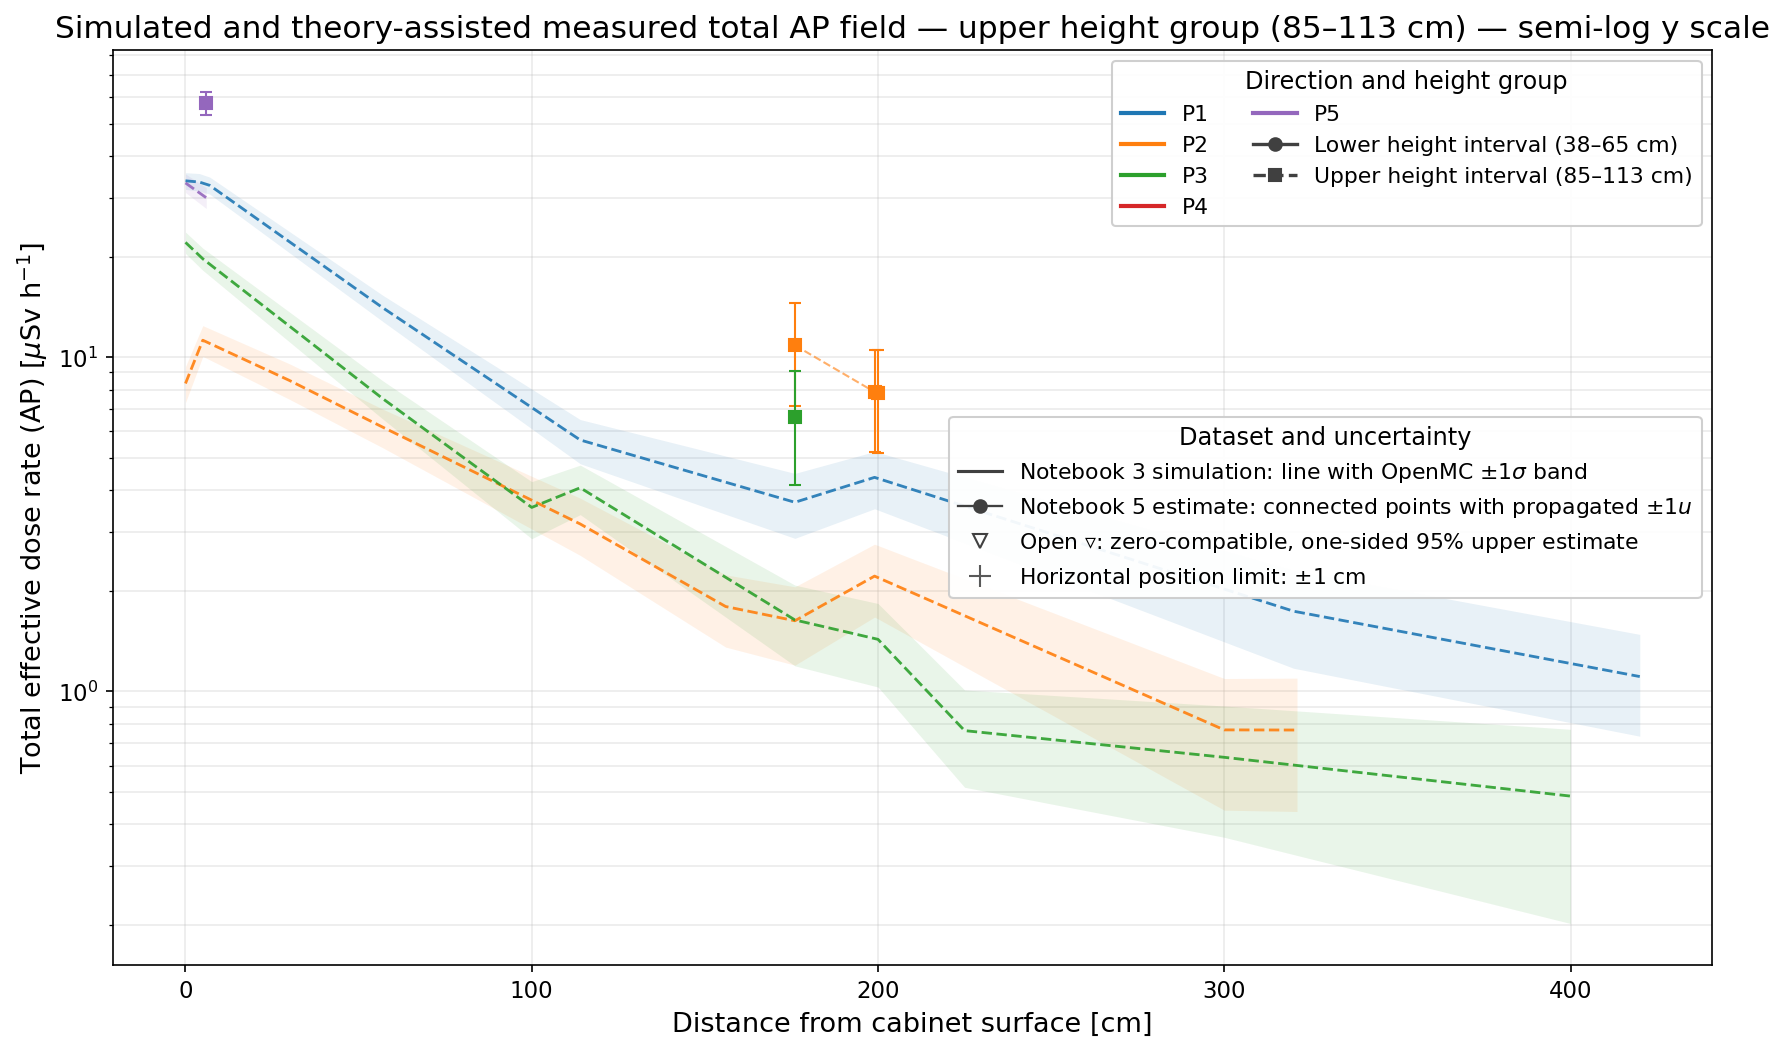

In [5]:
# ============================================================
# 5) Total-field overlays: all, lower, and upper height groups
# ============================================================

TOTAL_METHOD_HANDLES = [
    Line2D(
        [0], [0], color="0.25", linewidth=1.5,
        label=r"Notebook 3 simulation: line with OpenMC $\pm1\sigma$ band",
    ),
    Line2D(
        [0], [0], marker="o", color="0.25", linestyle="-",
        linewidth=1.1, markersize=6,
        label=r"Notebook 5 estimate: connected points with propagated $\pm1u$",
    ),
    Line2D(
        [0], [0], marker="v", markerfacecolor="none",
        markeredgecolor="0.25", color="none", linestyle="none",
        markersize=7, label=r"Open $\triangledown$: zero-compatible, one-sided 95% upper estimate",
    ),
    Line2D(
        [0], [0], marker="+", color="0.35", linestyle="none",
        markersize=11, label=r"Horizontal position limit: $\pm1$ cm",
    ),
]

HEIGHT_INTERVAL_HANDLES = [
    Line2D(
        [0], [0], color="0.25",
        linestyle=HEIGHT_INTERVAL_PLOT_SETTINGS[interval]["linestyle"],
        marker=HEIGHT_INTERVAL_PLOT_SETTINGS[interval]["marker"],
        linewidth=1.6,
        label=HEIGHT_INTERVAL_PLOT_SETTINGS[interval]["label"],
    )
    for interval in HEIGHT_INTERVAL_SEQUENCE
]


def plot_total_overlay(dataframe, title, method_legend_loc="lower left"):
    figure, axis = plt.subplots(
        figsize=(11.4, 6.9), dpi=150, layout="constrained"
    )

    for (position, interval, height_cm), curve in dataframe.groupby(
        ["position", "analysis_height_interval", "height_cm"],
        sort=True,
    ):
        if interval not in HEIGHT_INTERVAL_PLOT_SETTINGS:
            continue
        curve = curve.sort_values("distance_cm")
        settings = HEIGHT_INTERVAL_PLOT_SETTINGS[interval]
        color = POSITION_COLORS[position]

        simulation_curve = curve.loc[curve["simulation_available"]]
        if not simulation_curve.empty:
            plot_simulated_curve_with_band(
                axis,
                simulation_curve["distance_cm"],
                simulation_curve["simulated_total_ap_uSv_h"],
                simulation_curve["u_mc_simulated_total_ap_uSv_h"],
                color=color,
                linestyle=settings["linestyle"],
            )

        measured_curve = curve.loc[curve["total_comparison_available"]]
        if not measured_curve.empty:
            plot_measured_points(
                axis,
                measured_curve["distance_cm"],
                measured_curve["measured_total_ap_estimate_uSv_h"],
                measured_curve["u_measured_total_ap_estimate_uSv_h"],
                color=color,
                marker=settings["marker"],
                connect=True,
                connect_linestyle=settings["linestyle"],
                xerr=float(
                    measured_curve["horizontal_position_limit_cm"].median()
                ),
            )

    axis.set_yscale("log")
    axis.set_xlabel("Distance from cabinet surface [cm]")
    axis.set_ylabel(r"Total effective dose rate (AP) [$\mu$Sv h$^{-1}$]")
    axis.set_title(title)
    axis.grid(True, which="both", alpha=0.25)
    axis.set_axisbelow(True)

    position_handles = [
        Line2D(
            [0], [0], color=POSITION_COLORS[position], linewidth=2.0,
            label=position,
        )
        for position in POSITION_SEQUENCE
        if dataframe["position"].eq(position).any()
    ]
    group_legend = axis.legend(
        handles=position_handles + HEIGHT_INTERVAL_HANDLES,
        title="Direction and height group",
        loc="upper right",
        ncol=2,
        fontsize=FIGURE_LEGEND_FONTSIZE,
        title_fontsize=FIGURE_LEGEND_TITLE_FONTSIZE,
        framealpha=0.94,
        facecolor="white",
    )
    axis.add_artist(group_legend)
    axis.legend(
        handles=TOTAL_METHOD_HANDLES,
        title="Dataset and uncertainty",
        loc=method_legend_loc,
        fontsize=FIGURE_LEGEND_FONTSIZE,
        title_fontsize=FIGURE_LEGEND_TITLE_FONTSIZE,
        framealpha=0.94,
        facecolor="white",
    )
    return figure


total_all_figure = plot_total_overlay(
    comparison_df,
    "Simulated and theory-assisted measured total AP field "
    "— lower and upper height groups — semi-log y scale",
)
show_save_close(total_all_figure, "total_ap_overlay_all_target_heights")

total_lower_figure = plot_total_overlay(
    comparison_df.loc[comparison_df["analysis_height_interval"].eq("lower")],
    "Simulated and theory-assisted measured total AP field "
    "— lower height group (38–65 cm) — semi-log y scale",
)
show_save_close(total_lower_figure, "total_ap_overlay_lower_height")

total_upper_figure = plot_total_overlay(
    comparison_df.loc[comparison_df["analysis_height_interval"].eq("upper")],
    "Simulated and theory-assisted measured total AP field "
    "— upper height group (85–113 cm) — semi-log y scale",
    method_legend_loc="center right",
)
show_save_close(total_upper_figure, "total_ap_overlay_upper_height")


# 6) Position-wise total-field comparison

Each P-position is shown separately so a direction-dependent discrepancy is
not hidden in the combined plot. Only the common lower and upper height groups
appear in the legends. Notebook 5 values are connected within each actual
target-height series. Separate physical target heights within the same group
remain separate data series and are never connected to one another.


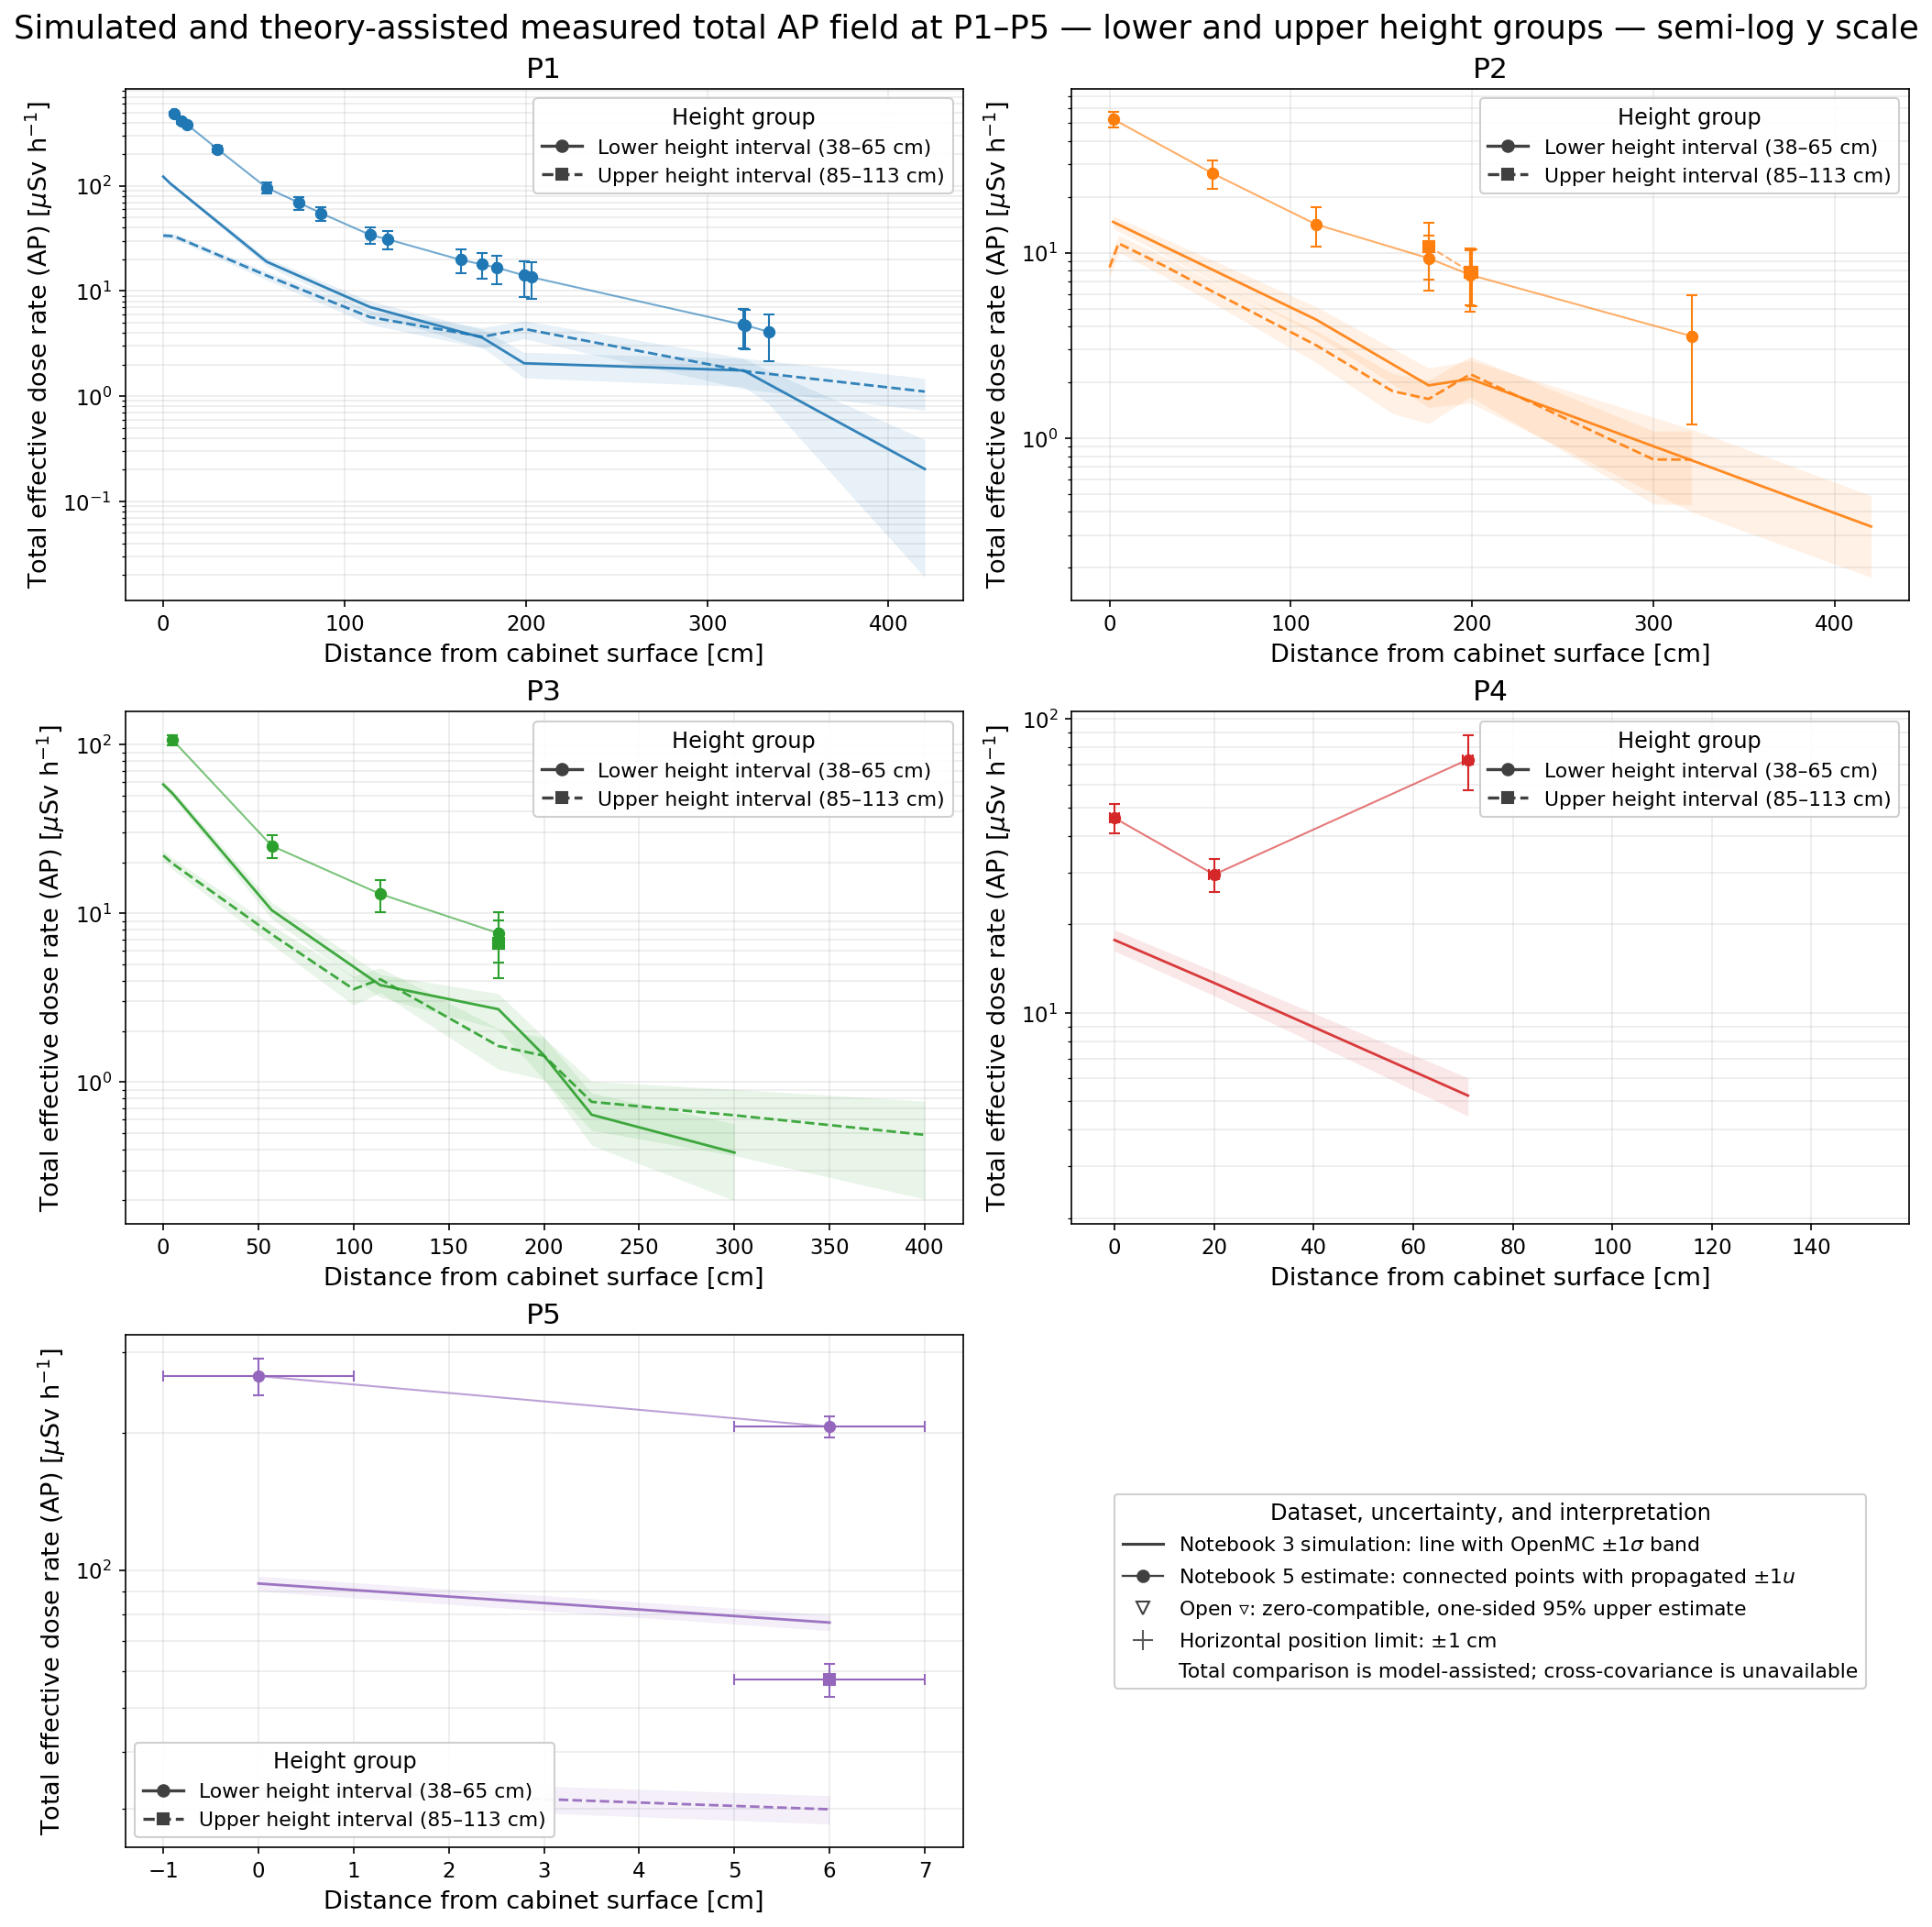

In [6]:
# ============================================================
# 6) Total-field overlay at P1–P5, grouped as lower and upper
# ============================================================

total_position_figure, total_position_axes = plt.subplots(
    3, 2, figsize=(13.8, 13.9), dpi=150, layout="constrained"
)
total_position_axes = total_position_axes.flatten()

for axis_index, position in enumerate(POSITION_SEQUENCE):
    axis = total_position_axes[axis_index]
    position_data = comparison_df.loc[comparison_df["position"].eq(position)]

    for (interval, height_cm), curve in position_data.groupby(
        ["analysis_height_interval", "height_cm"], sort=True
    ):
        if interval not in HEIGHT_INTERVAL_PLOT_SETTINGS:
            continue
        curve = curve.sort_values("distance_cm")
        settings = HEIGHT_INTERVAL_PLOT_SETTINGS[interval]
        color = POSITION_COLORS[position]

        simulated_curve = curve.loc[curve["simulation_available"]]
        if not simulated_curve.empty:
            plot_simulated_curve_with_band(
                axis,
                simulated_curve["distance_cm"],
                simulated_curve["simulated_total_ap_uSv_h"],
                simulated_curve["u_mc_simulated_total_ap_uSv_h"],
                color=color,
                linestyle=settings["linestyle"],
            )

        measured_curve = curve.loc[curve["total_comparison_available"]]
        if not measured_curve.empty:
            plot_measured_points(
                axis,
                measured_curve["distance_cm"],
                measured_curve["measured_total_ap_estimate_uSv_h"],
                measured_curve["u_measured_total_ap_estimate_uSv_h"],
                color=color,
                marker=settings["marker"],
                connect=True,
                connect_linestyle=settings["linestyle"],
                xerr=float(
                    measured_curve["horizontal_position_limit_cm"].median()
                ),
            )

    interval_handles = [
        handle
        for interval, handle in zip(
            HEIGHT_INTERVAL_SEQUENCE, HEIGHT_INTERVAL_HANDLES
        )
        if position_data["analysis_height_interval"].eq(interval).any()
    ]
    axis.set_yscale("log")
    axis.set_title(position)
    axis.set_xlabel("Distance from cabinet surface [cm]")
    axis.set_ylabel(r"Total effective dose rate (AP) [$\mu$Sv h$^{-1}$]")
    axis.grid(True, which="both", alpha=0.25)
    axis.set_axisbelow(True)
    axis.legend(
        handles=interval_handles,
        title="Height group",
        loc="lower left" if position == "P5" else "upper right",
        fontsize=FIGURE_LEGEND_FONTSIZE,
        title_fontsize=FIGURE_LEGEND_TITLE_FONTSIZE,
        framealpha=0.94,
        facecolor="white",
    )

total_position_axes[-1].axis("off")
total_position_axes[-1].legend(
    handles=TOTAL_METHOD_HANDLES + [
        Line2D(
            [0], [0], color="none", linestyle="none",
            label="Total comparison is model-assisted; cross-covariance is unavailable",
        ),
    ],
    title="Dataset, uncertainty, and interpretation",
    loc="center",
    fontsize=FIGURE_LEGEND_FONTSIZE,
    title_fontsize=FIGURE_LEGEND_TITLE_FONTSIZE,
    framealpha=0.94,
    facecolor="white",
)
total_position_figure.suptitle(
    "Simulated and theory-assisted measured total AP field at P1–P5 "
    "— lower and upper height groups — semi-log y scale",
    fontsize=FIGURE_SUPTITLE_FONTSIZE,
)

show_save_close(total_position_figure, "total_ap_overlay_by_position")


# 7) Neutron, gamma, and total component comparison

The component plot retains the Notebook 3/5 plotting syntax:

- neutron: solid line and circular measured markers;
- gamma: dashed line and square measured markers;
- total: hot-pink dash-dot line and diamond measured markers.

Notebook 3 uncertainty remains a translucent band. Notebook 5 uncertainty
remains a vertical point uncertainty. This figure is the main diagnostic for
whether an apparently good total is caused by compensating neutron and gamma
differences.


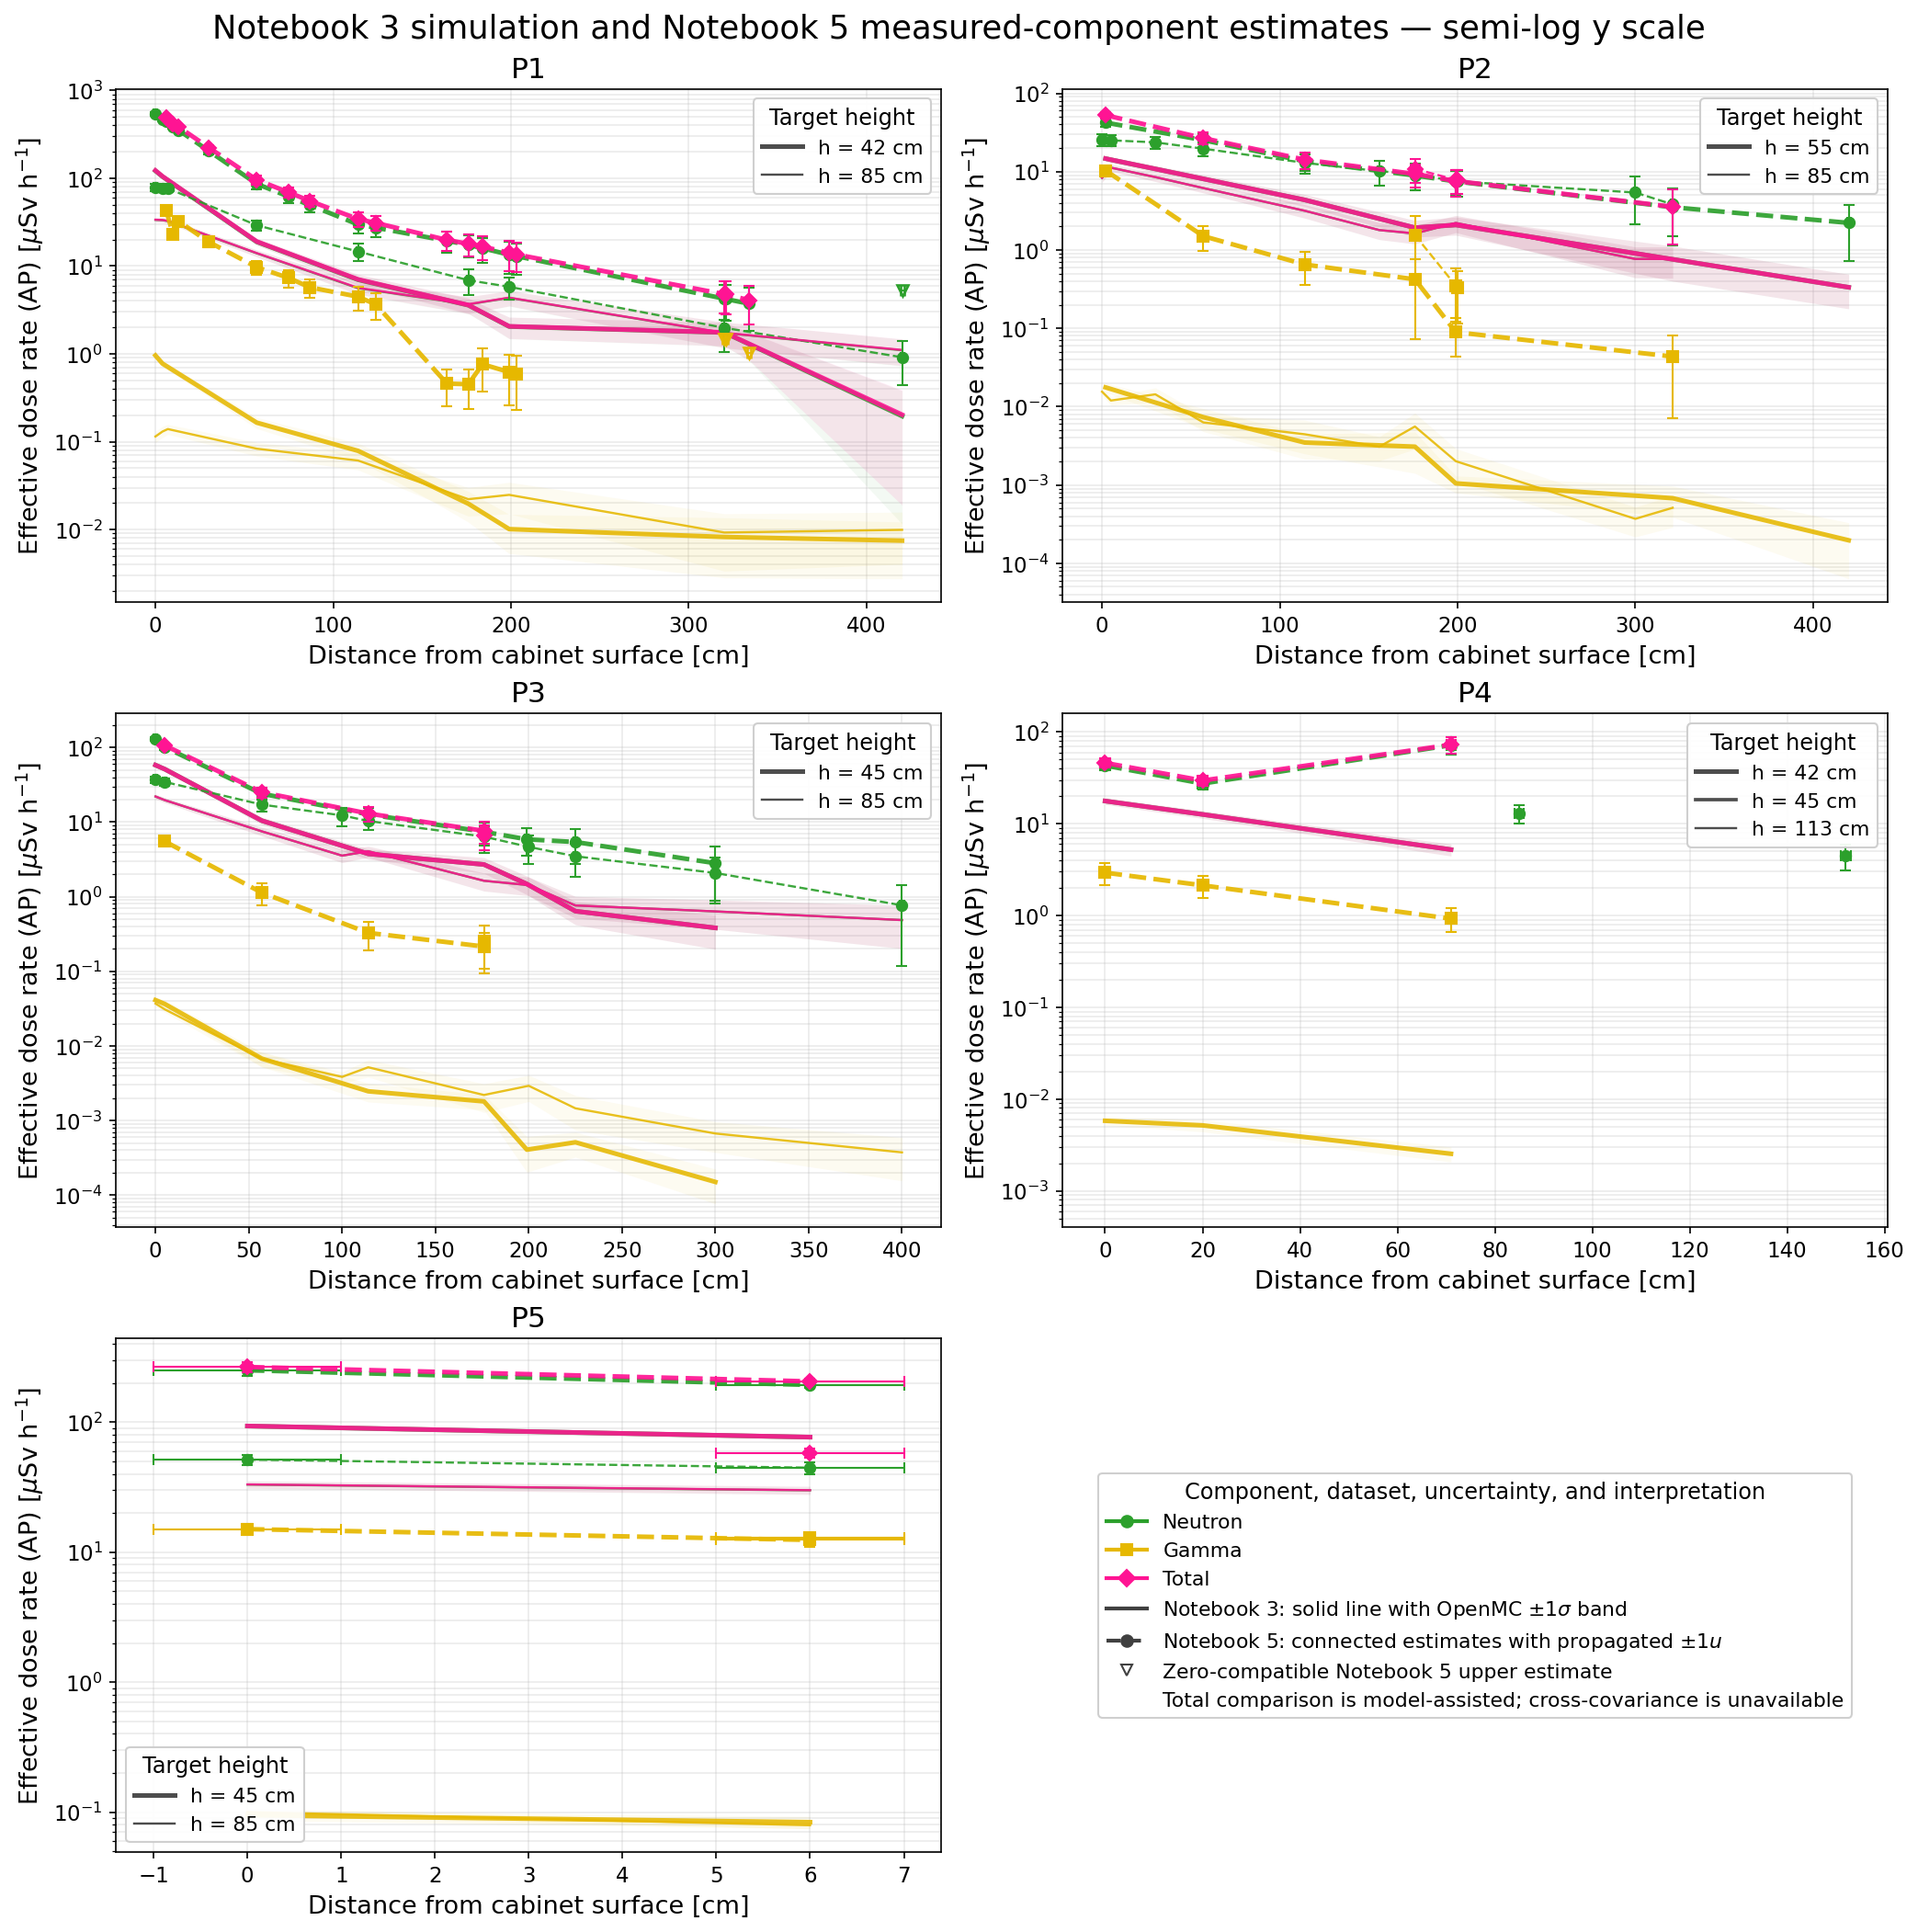

In [7]:
# ============================================================
# 7) Component overlays at P1–P5
# ============================================================

# Visual encoding:
#   Colour and marker = radiation component
#   Solid line + band = Notebook 3 simulation
#   Dashed connected markers = Notebook 5 estimate
#   Line width = target height

COMPONENT_COLORS = {
    "neutron": "#2CA02C",  # Green
    "gamma": "#E6B800",    # Readable yellow/gold
    "total": "#FF1493",    # Hot pink
}

component_plot_settings = [
    {
        "name": "neutron",
        "simulated": "simulated_neutron_ap_uSv_h",
        "u_simulated": "u_mc_simulated_neutron_ap_uSv_h",
        "measured": "measured_neutron_ap_component_uSv_h",
        "u_measured": "u_measured_neutron_ap_component_uSv_h",
        "available": "neutron_comparison_available",
        "color": COMPONENT_COLORS["neutron"],
        "marker": "o",
        "zorder": 2,
    },
    {
        "name": "gamma",
        "simulated": "simulated_gamma_ap_uSv_h",
        "u_simulated": "u_mc_simulated_gamma_ap_uSv_h",
        "measured": "measured_gamma_ap_component_uSv_h",
        "u_measured": "u_measured_gamma_ap_component_uSv_h",
        "available": "gamma_comparison_available",
        "color": COMPONENT_COLORS["gamma"],
        "marker": "s",
        "zorder": 3,
    },
    {
        "name": "total",
        "simulated": "simulated_total_ap_uSv_h",
        "u_simulated": "u_mc_simulated_total_ap_uSv_h",
        "measured": "measured_total_ap_estimate_uSv_h",
        "u_measured": "u_measured_total_ap_estimate_uSv_h",
        "available": "total_comparison_available",
        "color": COMPONENT_COLORS["total"],
        "marker": "D",
        "zorder": 4,
    },
]

component_figure, component_axes = plt.subplots(
    3,
    2,
    figsize=(13.8, 13.9),
    dpi=150,
    layout="constrained",
)
component_axes = component_axes.flatten()

for axis_index, position in enumerate(POSITION_SEQUENCE):
    axis = component_axes[axis_index]

    position_data = comparison_df.loc[
        comparison_df["position"].eq(position)
    ].copy()

    if position_data.empty:
        axis.set_visible(False)
        continue

    height_values = sorted(
        position_data["height_cm"].dropna().unique()
    )

    if len(height_values) == 1:
        height_linewidths = {
            float(height_values[0]): 2.0,
        }
    else:
        height_linewidths = dict(
            zip(
                [float(value) for value in height_values],
                np.linspace(2.4, 1.15, len(height_values)),
            )
        )

    height_handles = []

    for height_cm, curve in position_data.groupby(
        "height_cm",
        sort=True,
    ):
        curve = curve.sort_values("distance_cm")
        height_cm = float(height_cm)
        height_linewidth = height_linewidths[height_cm]

        for settings in component_plot_settings:
            component_color = settings["color"]
            component_zorder = settings["zorder"]

            # Notebook 3: solid simulated curve with OpenMC ±1σ band.
            simulated_curve = curve.loc[
                curve["simulation_available"].fillna(False)
            ].copy()

            if not simulated_curve.empty:
                plot_simulated_curve_with_band(
                    axis,
                    simulated_curve["distance_cm"],
                    simulated_curve[settings["simulated"]],
                    simulated_curve[settings["u_simulated"]],
                    color=component_color,
                    linestyle="-",
                    linewidth=height_linewidth,
                    alpha=0.88,
                    band_alpha=(
                        0.055
                        if settings["name"] != "total"
                        else 0.085
                    ),
                    zorder=component_zorder,
                )

            # Notebook 5: dashed connected estimates with error bars.
            measured_curve = curve.loc[
                curve[settings["available"]].fillna(False)
            ].copy()

            if measured_curve.empty:
                continue

            measured_curve = measured_curve.sort_values(
                "distance_cm"
            )

            measured_x = measured_curve[
                "distance_cm"
            ].to_numpy(dtype=float)

            measured_y = measured_curve[
                settings["measured"]
            ].to_numpy(dtype=float)

            measured_u = measured_curve[
                settings["u_measured"]
            ].to_numpy(dtype=float)

            regular = (
                np.isfinite(measured_x)
                & np.isfinite(measured_y)
                & np.isfinite(measured_u)
                & (measured_y > 0.0)
                & (measured_u >= 0.0)
                & ((measured_y - measured_u) > 0.0)
            )

            axis.plot(
                measured_x,
                np.where(regular, measured_y, np.nan),
                color=component_color,
                linestyle="--",
                linewidth=height_linewidth,
                alpha=0.92,
                zorder=component_zorder + 2,
            )

            plot_measured_points(
                axis,
                measured_x,
                measured_y,
                measured_u,
                color=component_color,
                marker=settings["marker"],
                connect=False,
                xerr=float(
                    measured_curve[
                        "horizontal_position_limit_cm"
                    ].median()
                ),
                zorder=component_zorder + 3,
            )

        height_handles.append(
            Line2D(
                [0],
                [0],
                color="0.30",
                linestyle="-",
                linewidth=height_linewidth,
                label=f"h = {height_cm:g} cm",
            )
        )

    axis.set_yscale("log")
    axis.set_title(position)
    axis.set_xlabel("Distance from cabinet surface [cm]")
    axis.set_ylabel(
        r"Effective dose rate (AP) [$\mu$Sv h$^{-1}$]"
    )
    axis.grid(True, which="both", alpha=0.25)
    axis.set_axisbelow(True)

    axis.legend(
        handles=height_handles,
        title="Target height",
        loc="lower left" if position == "P5" else "upper right",
        fontsize=FIGURE_LEGEND_FONTSIZE,
        title_fontsize=FIGURE_LEGEND_TITLE_FONTSIZE,
        framealpha=0.94,
        facecolor="white",
    )

component_axes[-1].axis("off")
component_axes[-1].legend(
    handles=[
        Line2D(
            [0],
            [0],
            color=COMPONENT_COLORS["neutron"],
            linestyle="-",
            marker="o",
            linewidth=2.0,
            label="Neutron",
        ),
        Line2D(
            [0],
            [0],
            color=COMPONENT_COLORS["gamma"],
            linestyle="-",
            marker="s",
            linewidth=2.0,
            label="Gamma",
        ),
        Line2D(
            [0],
            [0],
            color=COMPONENT_COLORS["total"],
            linestyle="-",
            marker="D",
            linewidth=2.0,
            label="Total",
        ),
        Line2D(
            [0],
            [0],
            color="0.25",
            linestyle="-",
            linewidth=2.0,
            label=r"Notebook 3: solid line with OpenMC $\pm1\sigma$ band",
        ),
        Line2D(
            [0],
            [0],
            color="0.25",
            linestyle="--",
            marker="o",
            linewidth=2.0,
            label=r"Notebook 5: connected estimates with propagated $\pm1u$",
        ),
        Line2D(
            [0],
            [0],
            color="none",
            marker="v",
            markerfacecolor="none",
            markeredgecolor="0.25",
            linestyle="none",
            label="Zero-compatible Notebook 5 upper estimate",
        ),
        Line2D(
            [0],
            [0],
            color="none",
            linestyle="none",
            label=(
                "Total comparison is model-assisted; "
                "cross-covariance is unavailable"
            ),
        ),
    ],
    title="Component, dataset, uncertainty, and interpretation",
    loc="center",
    fontsize=FIGURE_LEGEND_FONTSIZE,
    title_fontsize=FIGURE_LEGEND_TITLE_FONTSIZE,
    framealpha=0.94,
    facecolor="white",
)

component_figure.suptitle(
    "Notebook 3 simulation and Notebook 5 measured-component estimates "
    "— semi-log y scale",
    fontsize=FIGURE_SUPTITLE_FONTSIZE,
)

show_save_close(
    component_figure,
    "component_ap_overlay_by_position",
)

# 8) Descriptive ratios and relative residuals

Two complementary central-value diagnostics are retained:

$$
R = \frac{H_{\mathrm{sim}}}{H_{\mathrm{N5}}},
$$

and

$$
r_{\mathrm{rel}}
= 100\%\,\frac{H_{\mathrm{sim}}-H_{\mathrm{N5}}}{H_{\mathrm{N5}}}.
$$

Thus $R=1$ and $r_{\mathrm{rel}}=0\%$ both denote equality. Positive residuals
mean that Notebook 3 is higher than Notebook 5; negative residuals mean that
Notebook 3 is lower. The residual axes are linear because negative values are
physically meaningful.

Both quantities are descriptive central-value comparisons. No
uncertainty-normalized residual or independent uncertainty bar is assigned,
because Notebook 5 inherits Notebook 3 conversion-factor information and the
cross-covariance is unavailable.


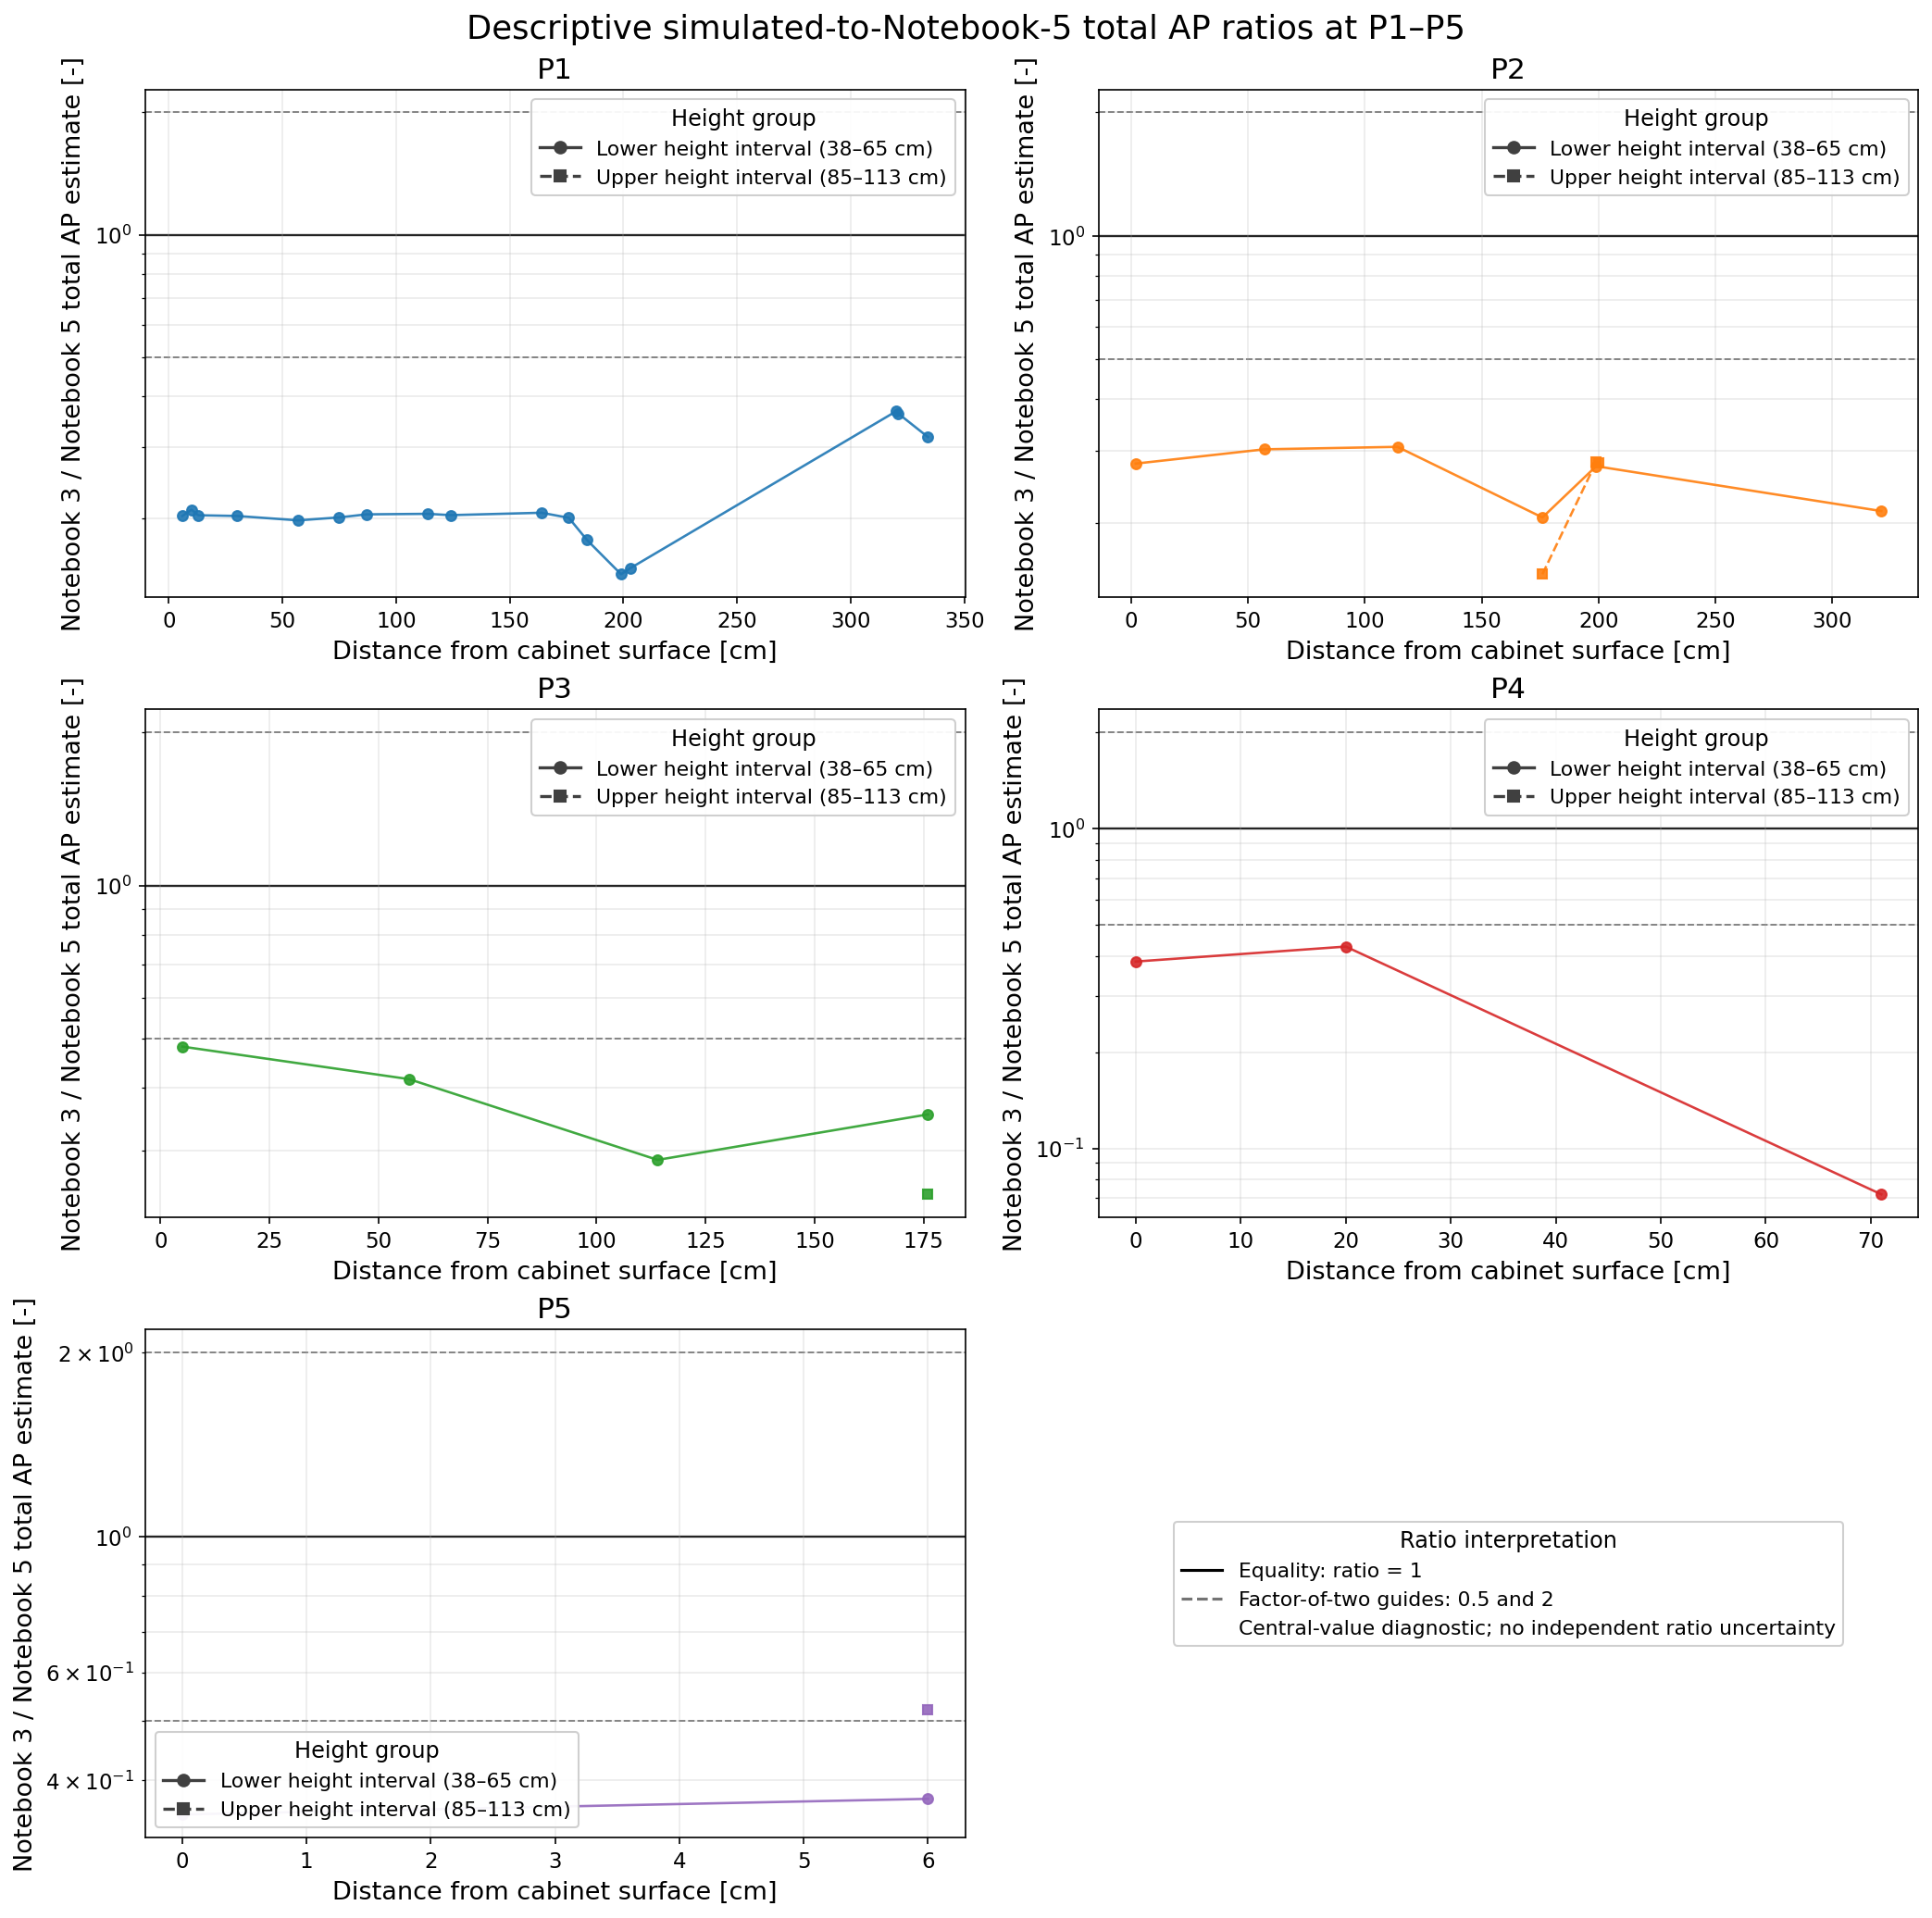

,component,position,analysis_height_interval,number_of_comparisons,geometric_mean_simulated_to_n5_ratio,median_simulated_to_n5_ratio,minimum_simulated_to_n5_ratio,maximum_simulated_to_n5_ratio,fraction_within_factor_two
0,neutron,P1,lower,20,0.222954,0.221375,0.118552,0.411738,0.000000
1,neutron,P1,upper,9,0.565770,0.479249,0.382064,1.200810,0.444444
2,neutron,P2,lower,7,0.254646,0.278055,0.150453,0.346702,0.000000
3,neutron,P2,upper,11,0.255218,0.291889,0.141830,0.446919,0.000000
4,neutron,P3,lower,8,0.284415,0.329806,0.118307,0.507564,0.125000
5,neutron,P3,upper,10,0.375526,0.349856,0.218728,0.633706,0.300000
6,neutron,P4,lower,4,0.259344,0.369492,0.072745,0.461138,0.000000
7,neutron,P4,upper,1,0.649909,0.649909,0.649909,0.649909,1.000000
8,neutron,P5,lower,2,0.384186,0.384374,0.372335,0.396414,0.000000
9,neutron,P5,upper,2,0.655948,0.656085,0.642688,0.669482,1.000000


In [8]:
# ============================================================
# 8.1) Position-wise total ratios and compact ratio summaries
# ============================================================

ratio_figure, ratio_axes = plt.subplots(
    3, 2, figsize=(13.8, 13.7), dpi=150, layout="constrained"
)
ratio_axes = ratio_axes.flatten()

for axis_index, position in enumerate(POSITION_SEQUENCE):
    axis = ratio_axes[axis_index]
    position_data = comparison_df.loc[comparison_df["position"].eq(position)]

    for (interval, height_cm), curve in position_data.groupby(
        ["analysis_height_interval", "height_cm"], sort=True
    ):
        if interval not in HEIGHT_INTERVAL_PLOT_SETTINGS:
            continue
        curve = curve.loc[curve["total_comparison_available"]].sort_values(
            "distance_cm"
        )
        if curve.empty:
            continue
        settings = HEIGHT_INTERVAL_PLOT_SETTINGS[interval]
        axis.plot(
            curve["distance_cm"],
            curve["simulated_to_n5_total_ratio"],
            marker=settings["marker"],
            linestyle=settings["linestyle"],
            markersize=5.2, linewidth=1.25,
            color=POSITION_COLORS[position], alpha=0.90,
        )

    interval_handles = [
        handle
        for interval, handle in zip(
            HEIGHT_INTERVAL_SEQUENCE, HEIGHT_INTERVAL_HANDLES
        )
        if position_data["analysis_height_interval"].eq(interval).any()
    ]
    axis.axhline(1.0, color="black", linewidth=1.1, zorder=0)
    axis.axhline(0.5, color="0.45", linewidth=0.9, linestyle="--", zorder=0)
    axis.axhline(2.0, color="0.45", linewidth=0.9, linestyle="--", zorder=0)
    axis.set_yscale("log")
    axis.set_title(position)
    axis.set_xlabel("Distance from cabinet surface [cm]")
    axis.set_ylabel("Notebook 3 / Notebook 5 total AP estimate [-]")
    axis.grid(True, which="both", alpha=0.25)
    axis.legend(
        handles=interval_handles,
        title="Height group",
        loc="lower left" if position == "P5" else "upper right",
        fontsize=FIGURE_LEGEND_FONTSIZE,
        title_fontsize=FIGURE_LEGEND_TITLE_FONTSIZE,
        framealpha=0.94,
    )

ratio_axes[-1].axis("off")
ratio_axes[-1].legend(
    handles=[
        Line2D([0], [0], color="black", label="Equality: ratio = 1"),
        Line2D([0], [0], color="0.45", linestyle="--",
               label="Factor-of-two guides: 0.5 and 2"),
        Line2D([0], [0], color="none", linestyle="none",
               label="Central-value diagnostic; no independent ratio uncertainty"),
    ],
    title="Ratio interpretation",
    loc="center",
    fontsize=FIGURE_LEGEND_FONTSIZE,
    title_fontsize=FIGURE_LEGEND_TITLE_FONTSIZE,
    framealpha=0.94,
)
ratio_figure.suptitle(
    "Descriptive simulated-to-Notebook-5 total AP ratios at P1–P5",
    fontsize=FIGURE_SUPTITLE_FONTSIZE,
)

show_save_close(ratio_figure, "total_ap_ratio_by_position")


ratio_summary_rows = []
for component, columns in component_definitions.items():
    ratio_column = f"simulated_to_n5_{component}_ratio"
    for (position, interval), group in comparison_df.groupby(
        ["position", "analysis_height_interval"], dropna=False, sort=True
    ):
        ratios = pd.to_numeric(group[ratio_column], errors="coerce")
        ratios = ratios[np.isfinite(ratios) & (ratios > 0.0)]
        ratio_summary_rows.append({
            "component": component,
            "position": position,
            "analysis_height_interval": interval,
            "number_of_comparisons": len(ratios),
            "geometric_mean_simulated_to_n5_ratio": (
                float(np.exp(np.mean(np.log(ratios)))) if len(ratios) else np.nan
            ),
            "median_simulated_to_n5_ratio": (
                float(np.median(ratios)) if len(ratios) else np.nan
            ),
            "minimum_simulated_to_n5_ratio": (
                float(np.min(ratios)) if len(ratios) else np.nan
            ),
            "maximum_simulated_to_n5_ratio": (
                float(np.max(ratios)) if len(ratios) else np.nan
            ),
            "fraction_within_factor_two": (
                float(np.mean((ratios >= 0.5) & (ratios <= 2.0)))
                if len(ratios) else np.nan
            ),
        })

ratio_summary_df = pd.DataFrame(ratio_summary_rows)
display(ratio_summary_df)


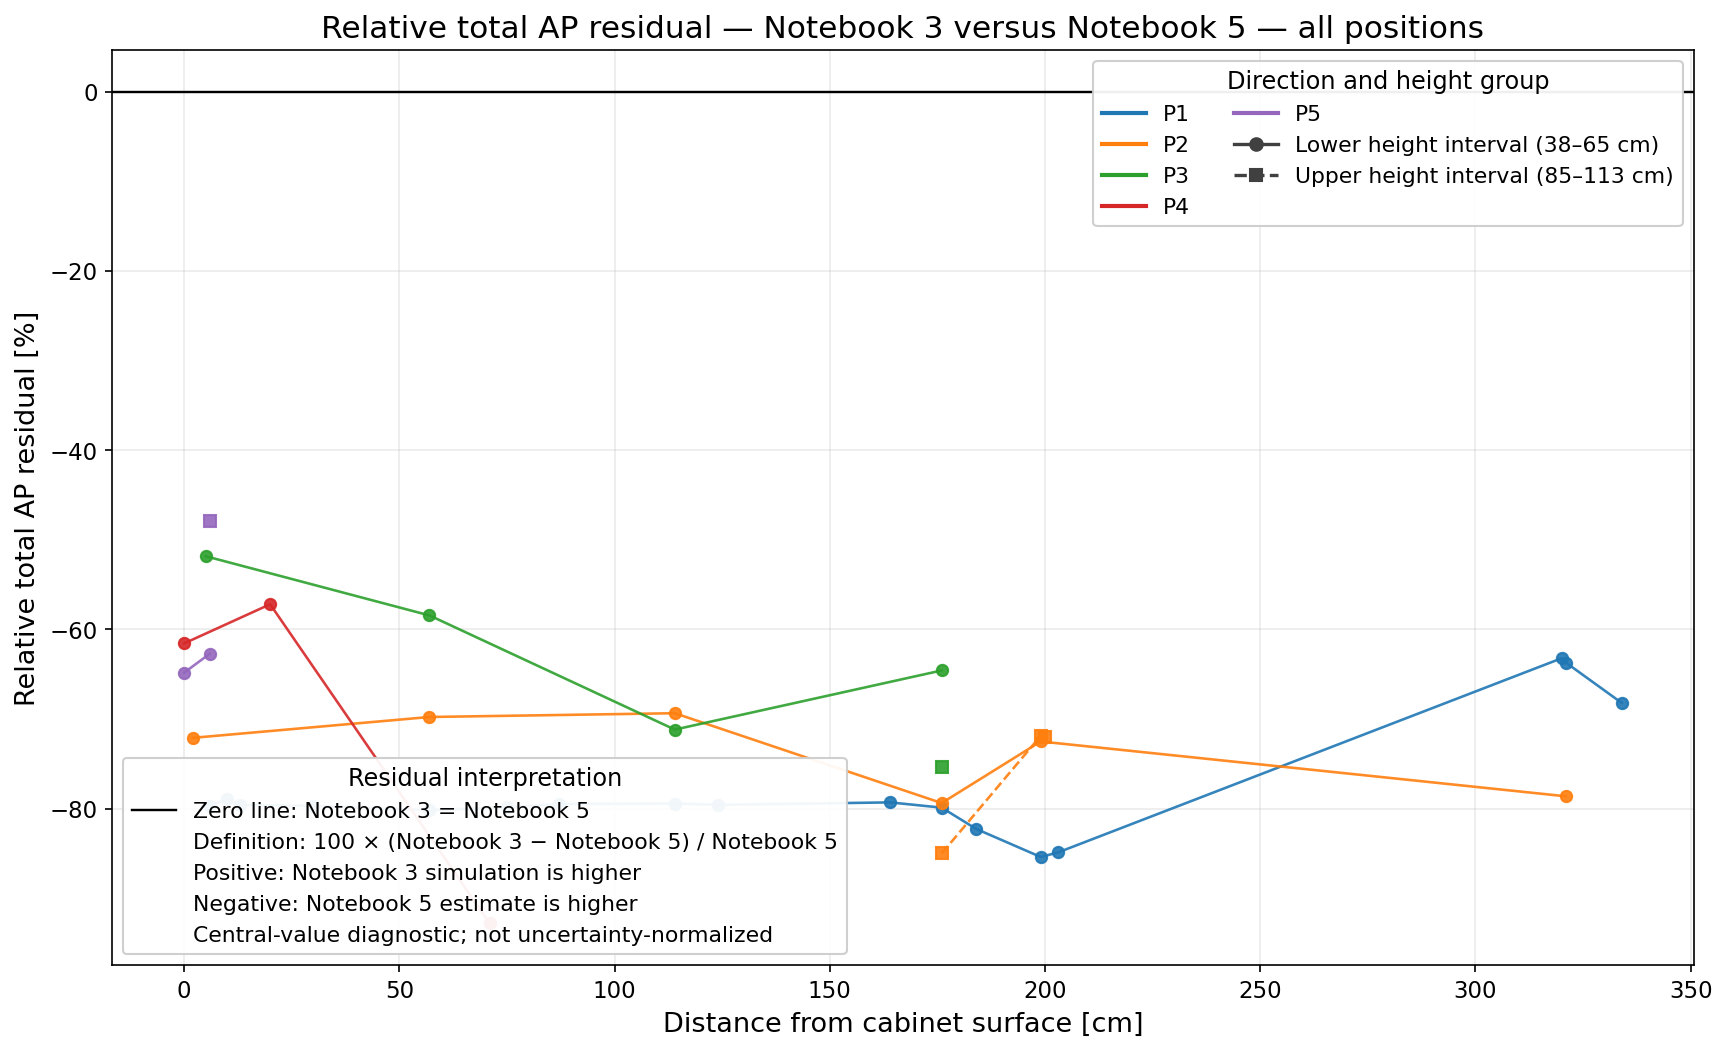

In [9]:
# ============================================================
# 8.2) Combined relative total residual: all positions
# ============================================================

RELATIVE_TOTAL_RESIDUAL_COLUMN = (
    "simulated_minus_n5_total_relative_residual_percent"
)

residual_all_figure, residual_all_axis = plt.subplots(
    figsize=(11.4, 6.9), dpi=150, layout="constrained"
)
residual_data = comparison_df.loc[
    comparison_df["total_comparison_available"]
].copy()

for (position, interval, height_cm), curve in residual_data.groupby(
    ["position", "analysis_height_interval", "height_cm"], sort=True
):
    if interval not in HEIGHT_INTERVAL_PLOT_SETTINGS:
        continue
    curve = curve.sort_values("distance_cm")
    settings = HEIGHT_INTERVAL_PLOT_SETTINGS[interval]
    residual_all_axis.plot(
        curve["distance_cm"],
        curve[RELATIVE_TOTAL_RESIDUAL_COLUMN],
        marker=settings["marker"],
        linestyle=settings["linestyle"],
        markersize=5.4, linewidth=1.25,
        color=POSITION_COLORS[position], alpha=0.90,
    )

residual_all_axis.axhline(
    0.0, color="black", linewidth=1.15,
    label="Zero line: Notebook 3 = Notebook 5",
)
residual_all_axis.set_xlabel("Distance from cabinet surface [cm]")
residual_all_axis.set_ylabel("Relative total AP residual [%]")
residual_all_axis.set_title(
    "Relative total AP residual — Notebook 3 versus Notebook 5 "
    "— all positions"
)
residual_all_axis.grid(True, alpha=0.25)
residual_all_axis.set_axisbelow(True)

residual_group_legend = residual_all_axis.legend(
    handles=[
        Line2D([0], [0], color=POSITION_COLORS[position], linewidth=2.0,
               label=position)
        for position in POSITION_SEQUENCE
        if residual_data["position"].eq(position).any()
    ] + HEIGHT_INTERVAL_HANDLES,
    title="Direction and height group",
    loc="upper right",
    ncol=2,
    fontsize=FIGURE_LEGEND_FONTSIZE,
    title_fontsize=FIGURE_LEGEND_TITLE_FONTSIZE,
    framealpha=0.94,
    facecolor="white",
)
residual_all_axis.add_artist(residual_group_legend)
residual_all_axis.legend(
    handles=[
        Line2D([0], [0], color="black", linewidth=1.15,
               label="Zero line: Notebook 3 = Notebook 5"),
        Line2D([0], [0], color="none", linestyle="none",
               label="Definition: 100 × (Notebook 3 − Notebook 5) / Notebook 5"),
        Line2D([0], [0], color="none", linestyle="none",
               label="Positive: Notebook 3 simulation is higher"),
        Line2D([0], [0], color="none", linestyle="none",
               label="Negative: Notebook 5 estimate is higher"),
        Line2D([0], [0], color="none", linestyle="none",
               label="Central-value diagnostic; not uncertainty-normalized"),
    ],
    title="Residual interpretation",
    loc="lower left",
    fontsize=FIGURE_LEGEND_FONTSIZE,
    title_fontsize=FIGURE_LEGEND_TITLE_FONTSIZE,
    framealpha=0.94,
    facecolor="white",
)

show_save_close(residual_all_figure, "relative_total_ap_residual_all_positions")


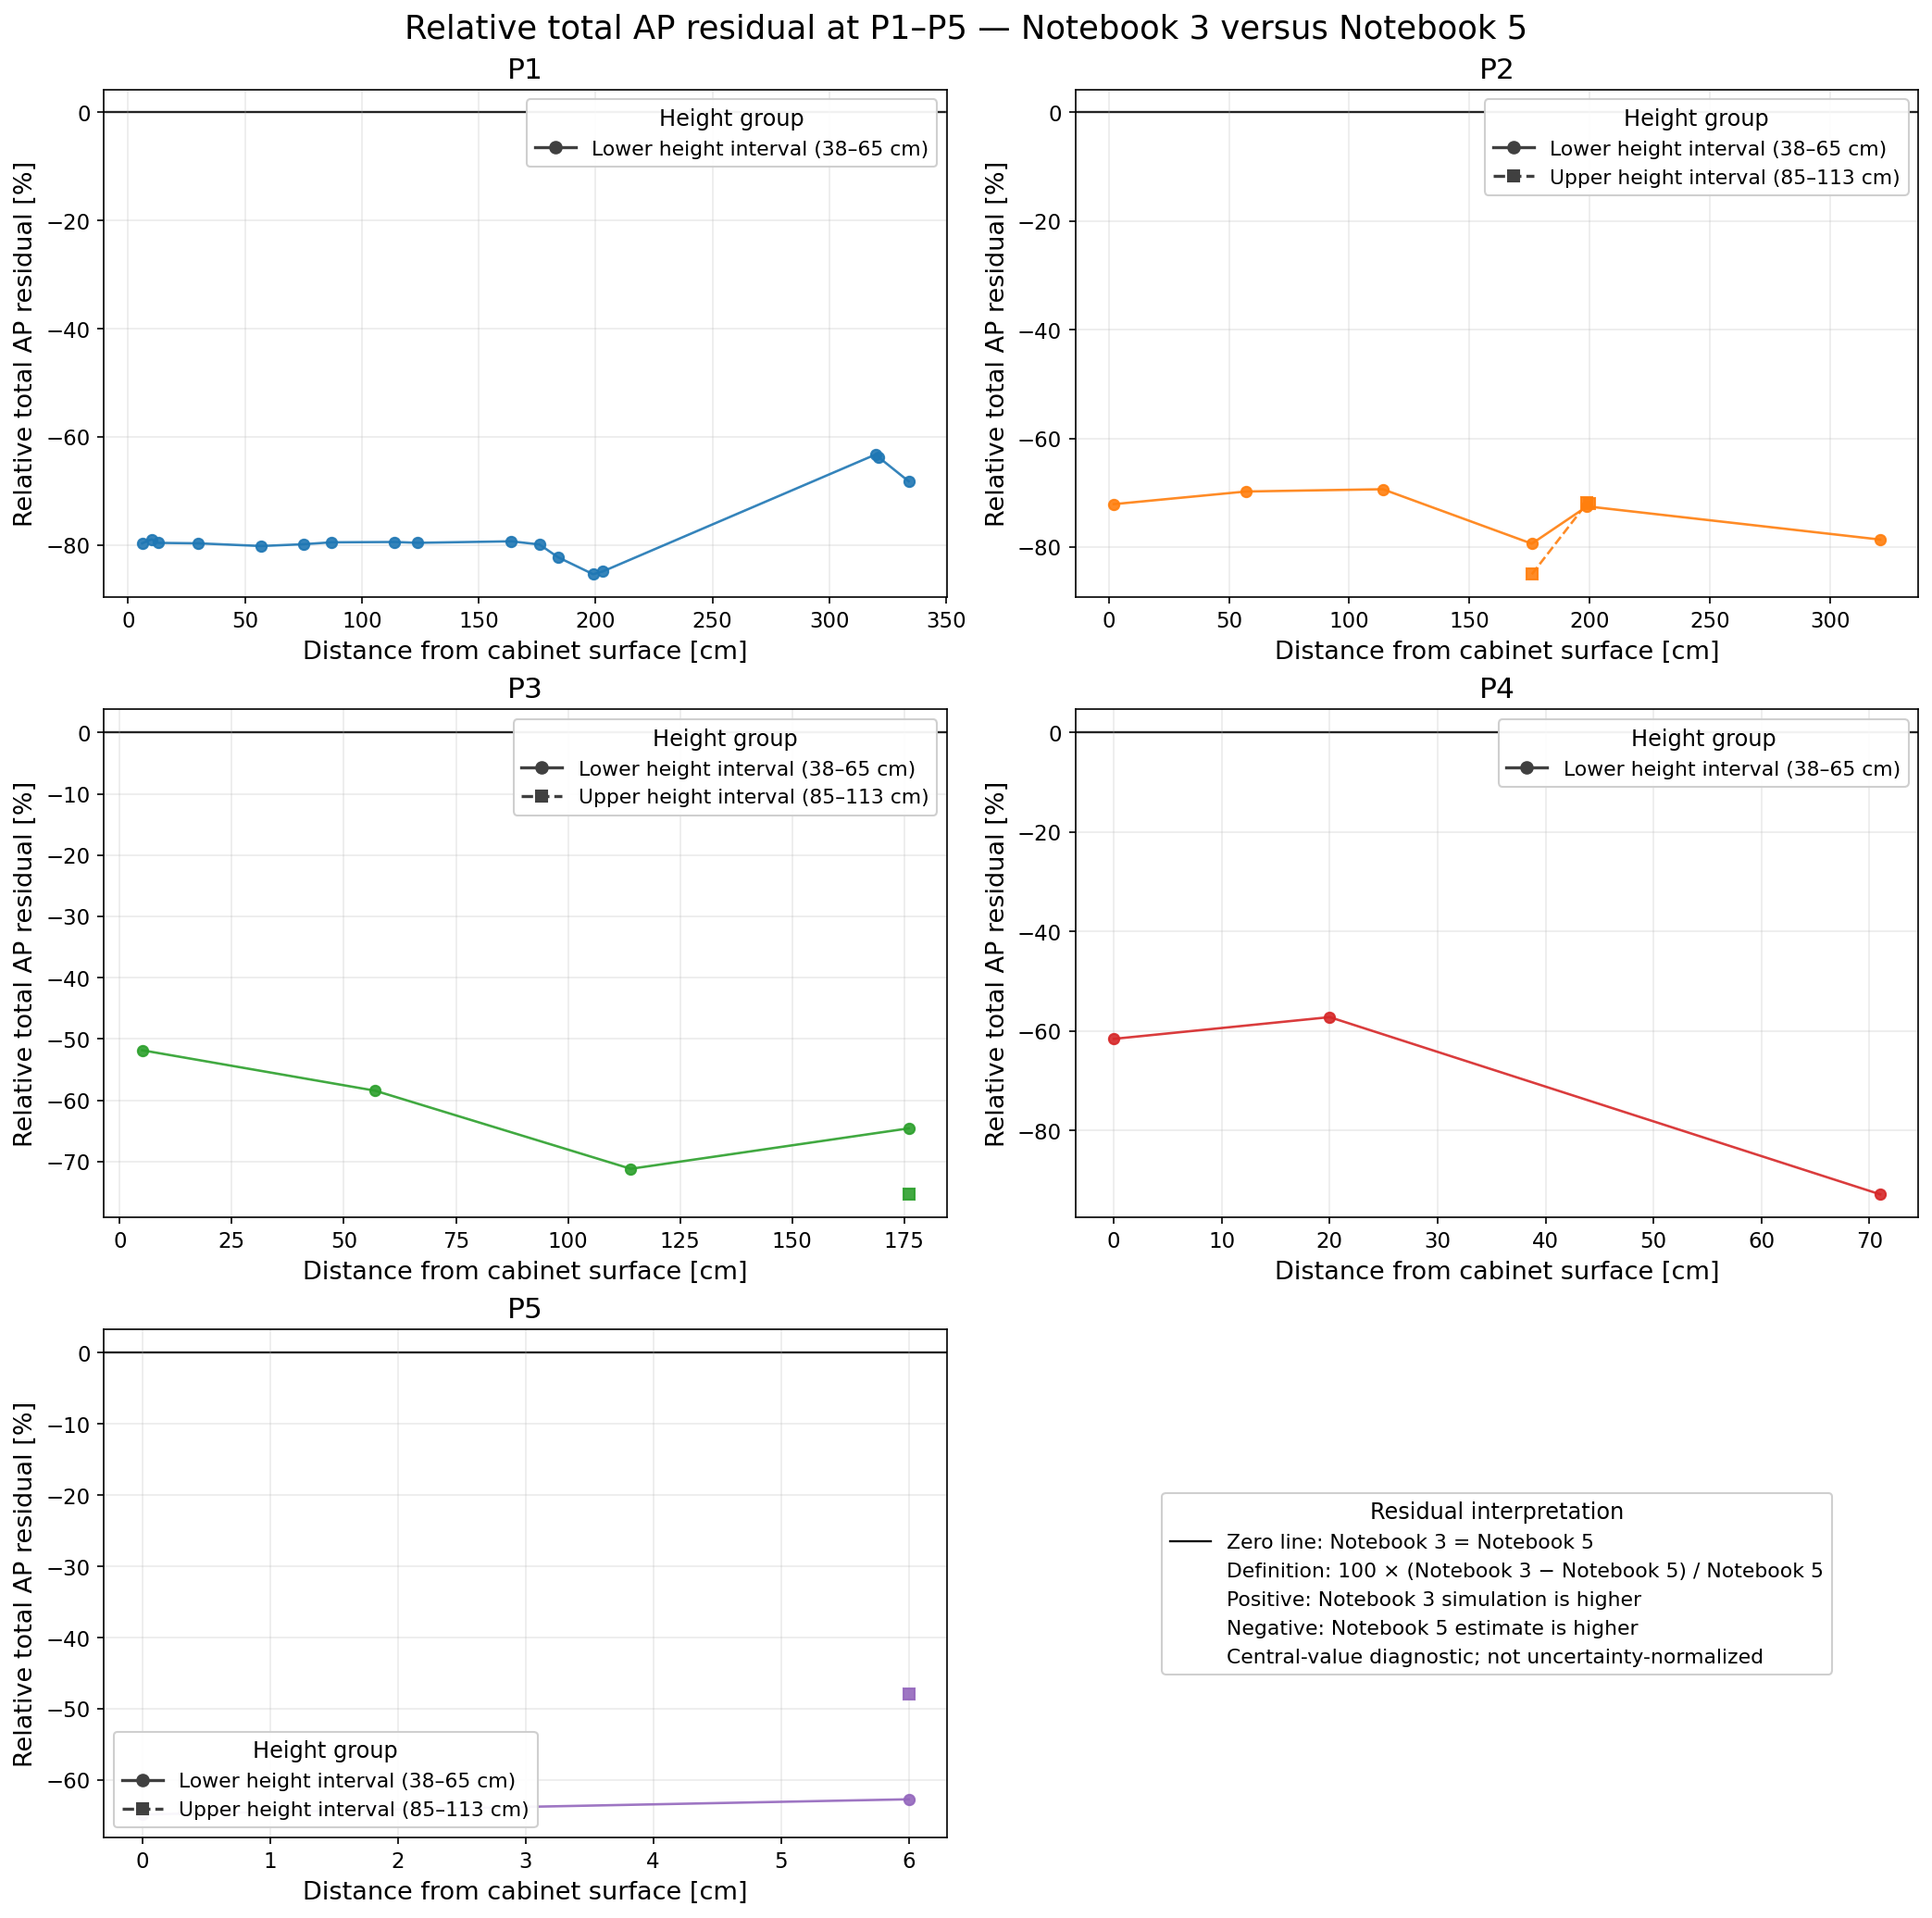

In [10]:
# ============================================================
# 8.3) Relative total residual at P1–P5
# ============================================================

residual_position_figure, residual_position_axes = plt.subplots(
    3, 2, figsize=(13.8, 13.7), dpi=150, layout="constrained"
)
residual_position_axes = residual_position_axes.flatten()

for axis_index, position in enumerate(POSITION_SEQUENCE):
    axis = residual_position_axes[axis_index]
    position_data = residual_data.loc[residual_data["position"].eq(position)]

    for (interval, height_cm), curve in position_data.groupby(
        ["analysis_height_interval", "height_cm"], sort=True
    ):
        if interval not in HEIGHT_INTERVAL_PLOT_SETTINGS:
            continue
        curve = curve.sort_values("distance_cm")
        settings = HEIGHT_INTERVAL_PLOT_SETTINGS[interval]
        axis.plot(
            curve["distance_cm"],
            curve[RELATIVE_TOTAL_RESIDUAL_COLUMN],
            marker=settings["marker"],
            linestyle=settings["linestyle"],
            markersize=5.4, linewidth=1.25,
            color=POSITION_COLORS[position], alpha=0.90,
        )

    interval_handles = [
        handle
        for interval, handle in zip(
            HEIGHT_INTERVAL_SEQUENCE, HEIGHT_INTERVAL_HANDLES
        )
        if position_data["analysis_height_interval"].eq(interval).any()
    ]
    axis.axhline(0.0, color="black", linewidth=1.1, zorder=0)
    axis.set_title(position)
    axis.set_xlabel("Distance from cabinet surface [cm]")
    axis.set_ylabel("Relative total AP residual [%]")
    axis.grid(True, alpha=0.25)
    axis.set_axisbelow(True)
    axis.legend(
        handles=interval_handles,
        title="Height group",
        loc="lower left" if position == "P5" else "upper right",
        fontsize=FIGURE_LEGEND_FONTSIZE,
        title_fontsize=FIGURE_LEGEND_TITLE_FONTSIZE,
        framealpha=0.94,
        facecolor="white",
    )

residual_position_axes[-1].axis("off")
residual_position_axes[-1].legend(
    handles=[
        Line2D([0], [0], color="black", linewidth=1.1,
               label="Zero line: Notebook 3 = Notebook 5"),
        Line2D([0], [0], color="none", linestyle="none",
               label="Definition: 100 × (Notebook 3 − Notebook 5) / Notebook 5"),
        Line2D([0], [0], color="none", linestyle="none",
               label="Positive: Notebook 3 simulation is higher"),
        Line2D([0], [0], color="none", linestyle="none",
               label="Negative: Notebook 5 estimate is higher"),
        Line2D([0], [0], color="none", linestyle="none",
               label="Central-value diagnostic; not uncertainty-normalized"),
    ],
    title="Residual interpretation",
    loc="center",
    fontsize=FIGURE_LEGEND_FONTSIZE,
    title_fontsize=FIGURE_LEGEND_TITLE_FONTSIZE,
    framealpha=0.94,
    facecolor="white",
)
residual_position_figure.suptitle(
    "Relative total AP residual at P1–P5 "
    "— Notebook 3 versus Notebook 5",
    fontsize=FIGURE_SUPTITLE_FONTSIZE,
)

show_save_close(
    residual_position_figure,
    "relative_total_ap_residual_by_position",
)


# 9) One-to-one component and total comparison

The log--log scatter panels compare Notebook 3 on the horizontal axis with
Notebook 5 on the vertical axis. The $1{:}1$ line and factor-of-two envelope
show the magnitude and direction of disagreement. Horizontal and vertical
uncertainties are displayed separately; they are not combined into a joint
significance statistic.


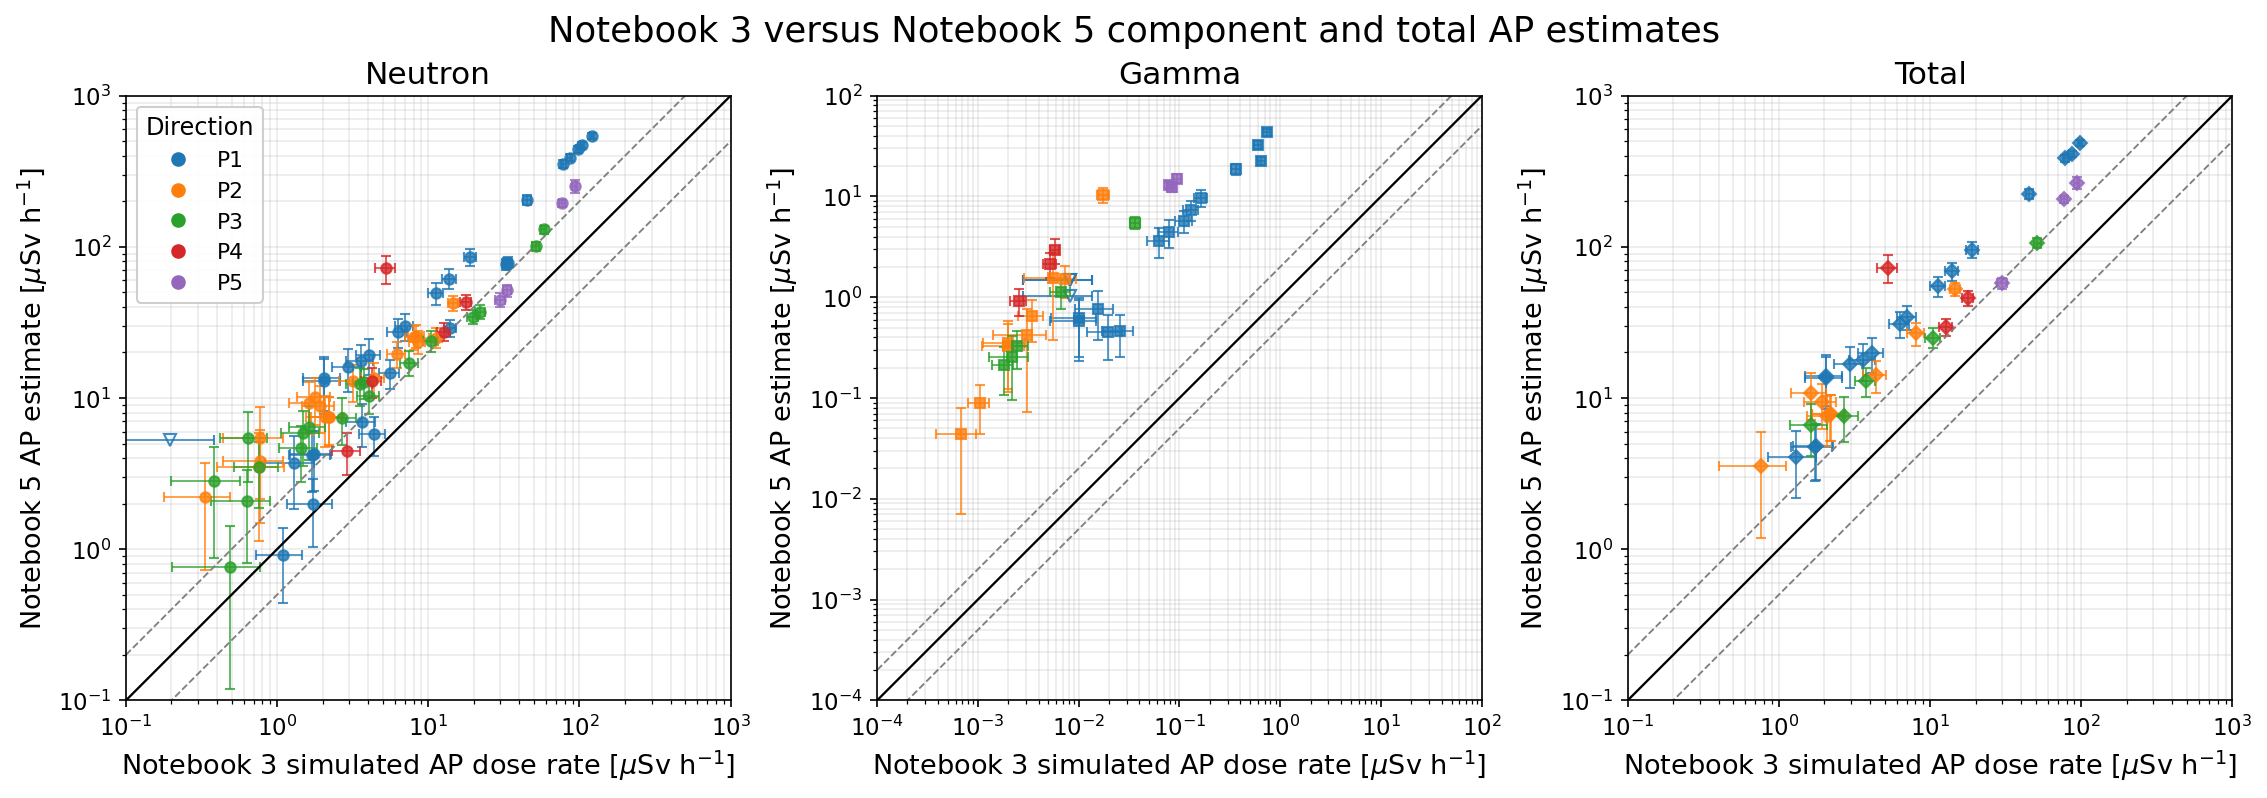

In [11]:
# ============================================================
# 9) One-to-one neutron, gamma, and total comparisons
# ============================================================

scatter_settings = [
    {
        "name": "Neutron",
        "available": "neutron_comparison_available",
        "x": "simulated_neutron_ap_uSv_h",
        "ux": "u_mc_simulated_neutron_ap_uSv_h",
        "y": "measured_neutron_ap_component_uSv_h",
        "uy": "u_measured_neutron_ap_component_uSv_h",
        "marker": "o",
    },
    {
        "name": "Gamma",
        "available": "gamma_comparison_available",
        "x": "simulated_gamma_ap_uSv_h",
        "ux": "u_mc_simulated_gamma_ap_uSv_h",
        "y": "measured_gamma_ap_component_uSv_h",
        "uy": "u_measured_gamma_ap_component_uSv_h",
        "marker": "s",
    },
    {
        "name": "Total",
        "available": "total_comparison_available",
        "x": "simulated_total_ap_uSv_h",
        "ux": "u_mc_simulated_total_ap_uSv_h",
        "y": "measured_total_ap_estimate_uSv_h",
        "uy": "u_measured_total_ap_estimate_uSv_h",
        "marker": "D",
    },
]

scatter_figure, scatter_axes = plt.subplots(
    1, 3, figsize=(15.0, 5.2), dpi=150, layout="constrained"
)

for axis, settings in zip(scatter_axes, scatter_settings):
    plot_data = comparison_df.loc[comparison_df[settings["available"]]].copy()
    finite = (
        np.isfinite(plot_data[settings["x"]])
        & (plot_data[settings["x"]] > 0.0)
        & np.isfinite(plot_data[settings["y"]])
        & (plot_data[settings["y"]] > 0.0)
        & np.isfinite(plot_data[settings["ux"]])
        & np.isfinite(plot_data[settings["uy"]])
    )
    plot_data = plot_data.loc[finite]

    for position in POSITION_SEQUENCE:
        group = plot_data.loc[plot_data["position"].eq(position)]
        if group.empty:
            continue
        x = group[settings["x"]].to_numpy(float)
        ux = group[settings["ux"]].to_numpy(float)
        y = group[settings["y"]].to_numpy(float)
        uy = group[settings["uy"]].to_numpy(float)
        regular = (x - ux > 0.0) & (y - uy > 0.0)
        zero_compatible = ~regular

        if np.any(regular):
            axis.errorbar(
                x[regular], y[regular],
                xerr=ux[regular], yerr=uy[regular],
                fmt=settings["marker"], linestyle="none",
                color=POSITION_COLORS[position],
                markerfacecolor=POSITION_COLORS[position],
                markeredgecolor=POSITION_COLORS[position],
                markersize=5.0, elinewidth=0.85, capsize=2.5,
                alpha=0.80,
            )
        if np.any(zero_compatible):
            upper_y = y[zero_compatible] + ONE_SIDED_95_Z * uy[zero_compatible]
            axis.errorbar(
                x[zero_compatible], upper_y,
                xerr=ux[zero_compatible],
                fmt="v", linestyle="none",
                color=POSITION_COLORS[position],
                markerfacecolor="none",
                markeredgecolor=POSITION_COLORS[position],
                markersize=6.0, elinewidth=0.85, capsize=2.5,
                alpha=0.85,
            )

    if not plot_data.empty:
        values = np.concatenate([
            plot_data[settings["x"]].to_numpy(float),
            plot_data[settings["y"]].to_numpy(float),
        ])
        lower = 10.0 ** np.floor(np.log10(np.nanmin(values)))
        upper = 10.0 ** np.ceil(np.log10(np.nanmax(values)))
        reference = np.logspace(np.log10(lower), np.log10(upper), 250)
        axis.plot(reference, reference, color="black", linewidth=1.1)
        axis.plot(reference, 2.0 * reference, color="0.5", linestyle="--", linewidth=0.9)
        axis.plot(reference, 0.5 * reference, color="0.5", linestyle="--", linewidth=0.9)
        axis.set_xlim(lower, upper)
        axis.set_ylim(lower, upper)

    axis.set_xscale("log")
    axis.set_yscale("log")
    axis.set_aspect("equal", adjustable="box")
    axis.set_title(settings["name"])
    axis.set_xlabel(r"Notebook 3 simulated AP dose rate [$\mu$Sv h$^{-1}$]")
    axis.set_ylabel(r"Notebook 5 AP estimate [$\mu$Sv h$^{-1}$]")
    axis.grid(True, which="both", alpha=0.25)

direction_handles = [
    Line2D(
        [0], [0], marker="o", linestyle="none",
        color=POSITION_COLORS[position], label=position,
    )
    for position in POSITION_SEQUENCE
]
scatter_axes[0].legend(
    handles=direction_handles,
    title="Direction",
    loc="upper left",
    fontsize=FIGURE_LEGEND_FONTSIZE,
    title_fontsize=FIGURE_LEGEND_TITLE_FONTSIZE,
    framealpha=0.94,
)
scatter_figure.suptitle(
    "Notebook 3 versus Notebook 5 component and total AP estimates",
    fontsize=FIGURE_SUPTITLE_FONTSIZE,
)

show_save_close(scatter_figure, "ap_one_to_one_components_and_total")


# 10) Spatial total-field agreement

The spatial map uses the shared Notebook 5 geometry and colours each
measurement-supported XY location by the median target-height value of

$$
\log_{10}\!\left(
\frac{\dot E_{\mathrm{AP,tot}}^{(N3)}}
     {\widehat{\dot E}_{\mathrm{AP,tot}}^{(N5)}}
\right).
$$

Zero denotes equal central values; $+0.301$ and $-0.301$ correspond to factors
of two. This is a spatial consistency map, not an uncertainty-significance
map.


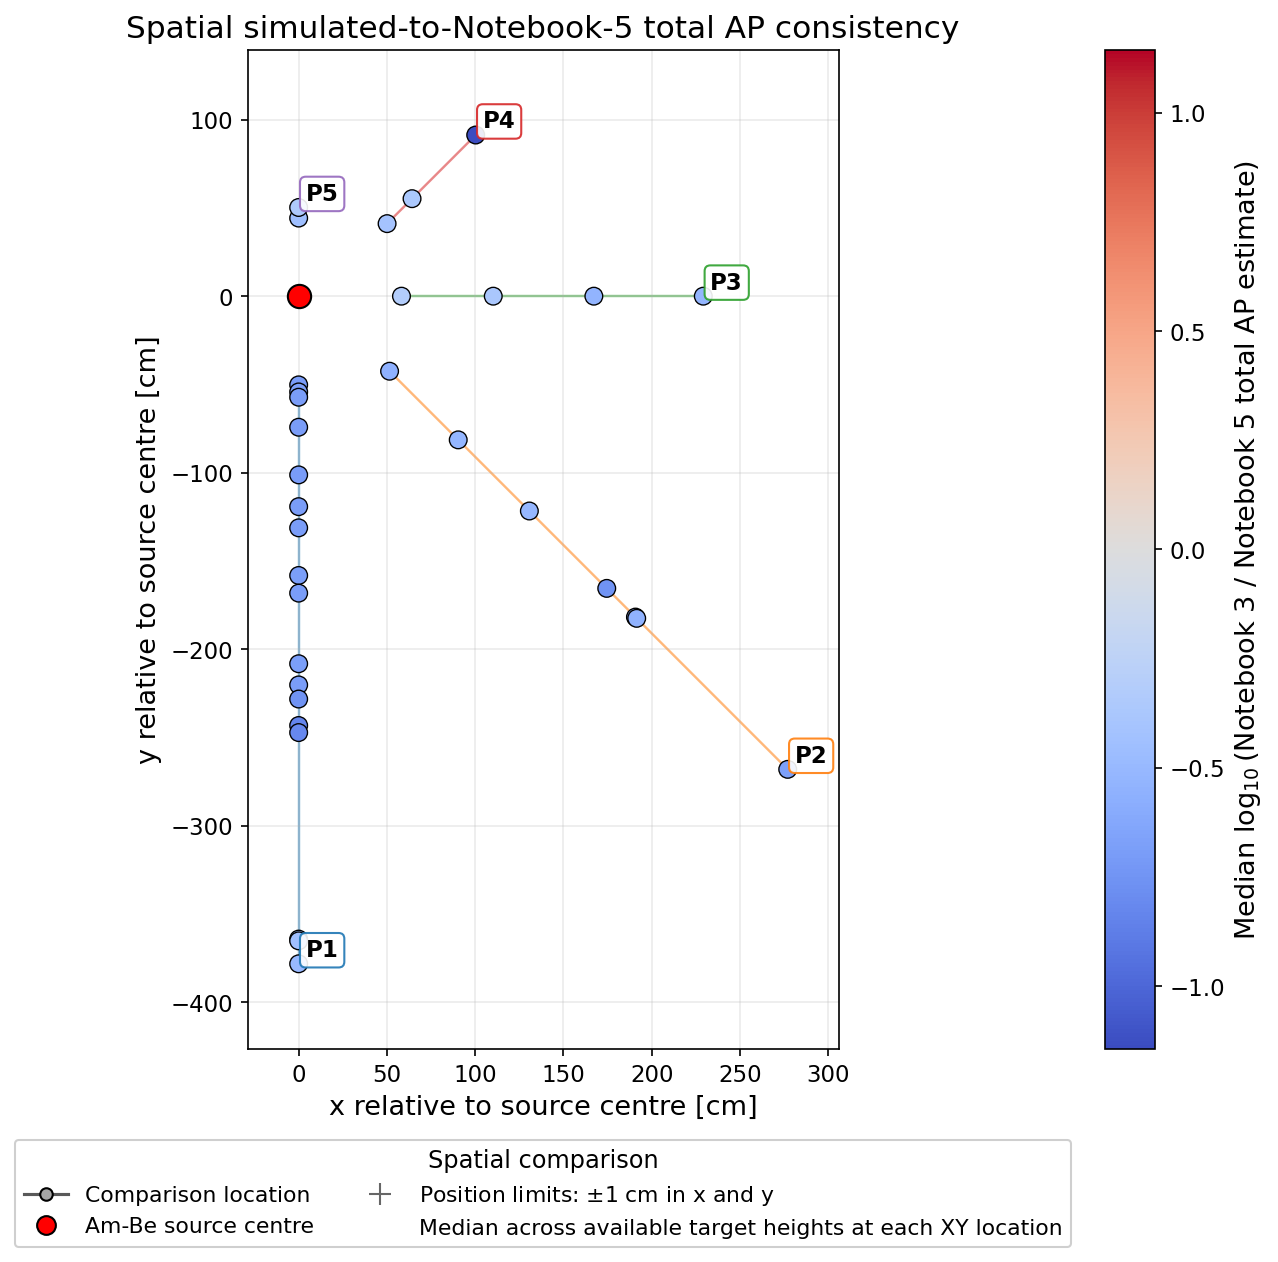

In [12]:
# ============================================================
# 10) Spatial map of the descriptive total ratio
# ============================================================

spatial_ratio_df = (
    comparison_df.loc[comparison_df["total_comparison_available"]]
    .groupby(
        [
            "position", "distance_cm", "common_dose_x_cm",
            "common_dose_y_cm",
        ],
        as_index=False,
    )
    .agg(
        median_log10_simulated_to_n5_total_ratio=(
            "log10_simulated_to_n5_total_ratio", "median"
        ),
        median_simulated_total_ap_uSv_h=("simulated_total_ap_uSv_h", "median"),
        median_notebook5_total_ap_uSv_h=(
            "measured_total_ap_estimate_uSv_h", "median"
        ),
        number_of_target_heights=("height_cm", "nunique"),
    )
)

spatial_figure, spatial_axis = plt.subplots(
    figsize=(9.3, 8.3), dpi=150, layout="constrained"
)

for position in POSITION_SEQUENCE:
    group = spatial_ratio_df.loc[
        spatial_ratio_df["position"].eq(position)
    ].sort_values("distance_cm")
    if group.empty:
        continue
    spatial_axis.plot(
        group["common_dose_x_cm"], group["common_dose_y_cm"],
        color=POSITION_COLORS[position], linewidth=1.15,
        alpha=0.55, zorder=1,
    )

spatial_axis.errorbar(
    spatial_ratio_df["common_dose_x_cm"],
    spatial_ratio_df["common_dose_y_cm"],
    xerr=DEFAULT_POSITION_LIMIT_CM,
    yerr=DEFAULT_POSITION_LIMIT_CM,
    fmt="none", ecolor="0.45", elinewidth=0.8,
    capsize=2.5, alpha=0.48, zorder=2,
)

finite_spatial_ratio = spatial_ratio_df[
    "median_log10_simulated_to_n5_total_ratio"
].to_numpy(float)
finite_spatial_ratio = finite_spatial_ratio[np.isfinite(finite_spatial_ratio)]
absolute_limit = max(
    0.30103,
    float(np.nanmax(np.abs(finite_spatial_ratio)))
    if finite_spatial_ratio.size else 0.30103,
)
spatial_norm = Normalize(vmin=-absolute_limit, vmax=absolute_limit)

spatial_scatter = spatial_axis.scatter(
    spatial_ratio_df["common_dose_x_cm"],
    spatial_ratio_df["common_dose_y_cm"],
    c=spatial_ratio_df["median_log10_simulated_to_n5_total_ratio"],
    cmap="coolwarm", norm=spatial_norm,
    s=72, edgecolor="black", linewidth=0.65, zorder=4,
)
spatial_axis.scatter(
    [0.0], [0.0], s=125, marker="o", color="red",
    edgecolor="black", zorder=6,
)

for position in POSITION_SEQUENCE:
    group = spatial_ratio_df.loc[spatial_ratio_df["position"].eq(position)]
    if group.empty:
        continue
    label_row = group.loc[group["distance_cm"].idxmax()]
    spatial_axis.text(
        label_row["common_dose_x_cm"] + 4.0,
        label_row["common_dose_y_cm"] + 4.0,
        position,
        fontsize=11,
        fontweight="bold",
        bbox={
            "boxstyle": "round,pad=0.25",
            "facecolor": "white",
            "edgecolor": POSITION_COLORS[position],
            "alpha": 0.90,
        },
        zorder=7,
    )

spatial_colorbar = spatial_figure.colorbar(
    spatial_scatter, ax=spatial_axis, pad=0.035
)
spatial_colorbar.set_label(
    r"Median $\log_{10}$(Notebook 3 / Notebook 5 total AP estimate)",
    fontsize=FIGURE_LABEL_FONTSIZE,
)
spatial_colorbar.ax.tick_params(labelsize=FIGURE_TICK_FONTSIZE)

spatial_axis.set_xlabel("x relative to source centre [cm]")
spatial_axis.set_ylabel("y relative to source centre [cm]")
spatial_axis.set_title("Spatial simulated-to-Notebook-5 total AP consistency")
spatial_axis.set_aspect("equal", adjustable="box")
spatial_axis.grid(True, alpha=0.25)
spatial_axis.margins(0.10)
spatial_axis.legend(
    handles=[
        Line2D([0], [0], marker="o", color="0.35", markerfacecolor="0.65",
               markeredgecolor="black", label="Comparison location"),
        Line2D([0], [0], marker="o", color="red", markeredgecolor="black",
               linestyle="none", markersize=9, label="Am-Be source centre"),
        Line2D([0], [0], marker="+", color="0.4", linestyle="none",
               markersize=11, label=r"Position limits: $\pm1$ cm in x and y"),
        Line2D([0], [0], color="none", linestyle="none",
               label="Median across available target heights at each XY location"),
    ],
    title="Spatial comparison",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.08),
    ncol=2,
    fontsize=FIGURE_LEGEND_FONTSIZE,
    title_fontsize=FIGURE_LEGEND_TITLE_FONTSIZE,
    framealpha=0.94,
    facecolor="white",
)

show_save_close(spatial_figure, "spatial_total_ap_consistency_ratio")


# 11) Export the Notebook 6 comparison handoff

The final table retains both central values, both marginal uncertainty
descriptions, all interpolation flags, component ratios, relative residuals,
and total ratios.
No covariance-free normalized residual is exported because it would imply
statistical independence that the analysis does not have.


In [13]:
# ============================================================
# 11) Save final tables, metadata, and figure inventory
# ============================================================

tables_to_save = {
    "simulation_vs_notebook5_common_grid_final.csv": comparison_df,
    "comparison_coverage_summary.csv": coverage_summary_df,
    "comparison_ratio_summary.csv": ratio_summary_df,
    "spatial_total_ap_consistency_ratio.csv": spatial_ratio_df,
    "comparison_methodology_audit.csv": methodology_audit_df,
    "input_audit.csv": input_audit_df,
}

saved_table_rows = []
for filename, dataframe in tables_to_save.items():
    path = TABLE_DIR / filename
    dataframe.to_csv(path, index=False)
    saved_table_rows.append({
        "filename": filename,
        "path": str(path.resolve()),
        "rows": len(dataframe),
    })
saved_tables_df = pd.DataFrame(saved_table_rows)

saved_figures_df = pd.DataFrame(exported_figure_rows)
figure_inventory_path = METADATA_DIR / "notebook_6_figure_inventory.csv"
saved_figures_df.to_csv(figure_inventory_path, index=False)

metadata_df = pd.DataFrame([
    {
        "quantity": "notebook",
        "value": "Notebook_6.ipynb",
        "unit": "",
        "note": "Notebook 3 simulation versus Notebook 5 theory-assisted measured AP field",
    },
    {
        "quantity": "comparison_grid",
        "value": "Notebook 5 common target grid",
        "unit": "",
        "note": "all measurement-supported distances at exact Notebook 3 target heights",
    },
    {
        "quantity": "simulated_interpolation",
        "value": "positive log-linear interpolation in distance",
        "unit": "",
        "note": "same P-position and exact target height; no extrapolation",
    },
    {
        "quantity": "Notebook_3_uncertainty_display",
        "value": "OpenMC batch-statistical ±1 standard uncertainty band",
        "unit": "",
        "note": "marginal simulation sampling uncertainty",
    },
    {
        "quantity": "Notebook_5_uncertainty_display",
        "value": "propagated ±1 standard uncertainty point bar",
        "unit": "",
        "note": "measurement SEM plus Notebook 3 conversion-factor MC term",
    },
    {
        "quantity": "zero_compatible_display",
        "value": "one-sided 95% upper estimate",
        "unit": "",
        "note": "open downward triangle; point not connected as a central curve value",
    },
    {
        "quantity": "ratio_definition",
        "value": "Notebook 3 simulated value / Notebook 5 estimate",
        "unit": "dimensionless",
        "note": "central-value diagnostic only",
    },
    {
        "quantity": "relative_residual_definition",
        "value": "100 * (Notebook 3 simulated - Notebook 5 estimate) / Notebook 5 estimate",
        "unit": "%",
        "note": "descriptive central-value residual; positive means simulation is higher",
    },
    {
        "quantity": "cross_covariance",
        "value": "unavailable",
        "unit": "",
        "note": "no independence-assuming combined uncertainty or z score is reported",
    },
    {
        "quantity": "total_comparison_status",
        "value": "model-assisted consistency test",
        "unit": "",
        "note": "Notebook 5 uses Notebook 3 component conversion fields",
    },
])
metadata_path = METADATA_DIR / "notebook_6_analysis_metadata.csv"
metadata_df.to_csv(metadata_path, index=False)

summary_json = {
    "analysis": "Notebook 3 simulation versus Notebook 5 theory-assisted measured AP field",
    "comparison_grid_rows": int(len(comparison_df)),
    "simulation_available_rows": int(comparison_df["simulation_available"].sum()),
    "neutron_comparisons": int(comparison_df["neutron_comparison_available"].sum()),
    "gamma_comparisons": int(comparison_df["gamma_comparison_available"].sum()),
    "total_comparisons": int(comparison_df["total_comparison_available"].sum()),
    "simulated_extrapolation_used": False,
    "ratio_uncertainty_propagated_as_independent": False,
    "uncertainty_normalized_residual_reported": False,
    "result_is_independent_validation": False,
    "canonical_output": str(
        TABLE_DIR / "simulation_vs_notebook5_common_grid_final.csv"
    ),
}
summary_json_path = METADATA_DIR / "notebook_6_analysis_summary.json"
summary_json_path.write_text(
    json.dumps(summary_json, indent=2) + "\n", encoding="utf-8"
)

print("Notebook 6 outputs saved.")
print(
    "Canonical comparison table: "
    f"{TABLE_DIR / 'simulation_vs_notebook5_common_grid_final.csv'}"
)
print(f"Metadata: {metadata_path}")
print(f"Figures: {len(saved_figures_df)}")
display(saved_tables_df)
display(saved_figures_df)


Notebook 6 outputs saved.
Canonical comparison table: /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N6_simulation_vs_measurement_outputs/tables/simulation_vs_notebook5_common_grid_final.csv
Metadata: /root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N6_simulation_vs_measurement_outputs/metadata/notebook_6_analysis_metadata.csv
Figures: 10


,filename,path,rows
0,simulation_vs_notebook5_common_grid_final.csv,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N6_simulation_vs_measurement_outputs/tables/simulation_vs_notebook5_common_grid_final.csv,81
1,comparison_coverage_summary.csv,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N6_simulation_vs_measurement_outputs/tables/comparison_coverage_summary.csv,10
2,comparison_ratio_summary.csv,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N6_simulation_vs_measurement_outputs/tables/comparison_ratio_summary.csv,30
3,spatial_total_ap_consistency_ratio.csv,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N6_simulation_vs_measurement_outputs/tables/spatial_total_ap_consistency_ratio.csv,33
4,comparison_methodology_audit.csv,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N6_simulation_vs_measurement_outputs/tables/comparison_methodology_audit.csv,6
5,input_audit.csv,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N6_simulation_vs_measurement_outputs/tables/input_audit.csv,2


,stem,png_path,pdf_path
0,total_ap_overlay_all_target_heights,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N6_simulation_vs_measurement_outputs/figures/total_ap_overlay_all_target_heights.png,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N6_simulation_vs_measurement_outputs/figures/total_ap_overlay_all_target_heights.pdf
1,total_ap_overlay_lower_height,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N6_simulation_vs_measurement_outputs/figures/total_ap_overlay_lower_height.png,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N6_simulation_vs_measurement_outputs/figures/total_ap_overlay_lower_height.pdf
2,total_ap_overlay_upper_height,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N6_simulation_vs_measurement_outputs/figures/total_ap_overlay_upper_height.png,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N6_simulation_vs_measurement_outputs/figures/total_ap_overlay_upper_height.pdf
3,total_ap_overlay_by_position,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N6_simulation_vs_measurement_outputs/figures/total_ap_overlay_by_position.png,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N6_simulation_vs_measurement_outputs/figures/total_ap_overlay_by_position.pdf
4,component_ap_overlay_by_position,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N6_simulation_vs_measurement_outputs/figures/component_ap_overlay_by_position.png,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N6_simulation_vs_measurement_outputs/figures/component_ap_overlay_by_position.pdf
5,total_ap_ratio_by_position,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N6_simulation_vs_measurement_outputs/figures/total_ap_ratio_by_position.png,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N6_simulation_vs_measurement_outputs/figures/total_ap_ratio_by_position.pdf
6,relative_total_ap_residual_all_positions,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N6_simulation_vs_measurement_outputs/figures/relative_total_ap_residual_all_positions.png,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N6_simulation_vs_measurement_outputs/figures/relative_total_ap_residual_all_positions.pdf
7,relative_total_ap_residual_by_position,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N6_simulation_vs_measurement_outputs/figures/relative_total_ap_residual_by_position.png,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N6_simulation_vs_measurement_outputs/figures/relative_total_ap_residual_by_position.pdf
8,ap_one_to_one_components_and_total,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N6_simulation_vs_measurement_outputs/figures/ap_one_to_one_components_and_total.png,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N6_simulation_vs_measurement_outputs/figures/ap_one_to_one_components_and_total.pdf
9,spatial_total_ap_consistency_ratio,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N6_simulation_vs_measurement_outputs/figures/spatial_total_ap_consistency_ratio.png,/root/Rfys_VI/RFP-master/Bachelor_projekt/NF_AmBe_Parafifn/N6_simulation_vs_measurement_outputs/figures/spatial_total_ap_consistency_ratio.pdf


# 12) Summary, interpretation, and limitations

Notebook 6 now compares Notebook 3 and Notebook 5 on one transparent common
grid. All measurement-supported distances are retained when they lie inside a
Notebook 3 curve with the same P-position and exact target height. The former
nearest-point matching and sparse exact-pair-only plots have been removed.

The total overlay is directly usable as a report-oriented consistency figure:
Notebook 3 is a line with its OpenMC $1\sigma$ band, and Notebook 5 is a point
series with its propagated standard uncertainty. The two displays should not
be made visually identical because they describe different uncertainty
sources. Zero-compatible Notebook 5 points are shown as upper estimates so a
logarithmic axis does not create misleading multi-decade error bars.

The central ratios and relative residuals describe agreement. The relative
residual is defined as
$100\%(H_{\mathrm{sim}}-H_{\mathrm{N5}})/H_{\mathrm{N5}}$ and is shown both for
all positions together and for P1--P5 separately. No uncertainty-normalized
residual is claimed. Notebook 5's conversion fields are derived from Notebook
3, so the cross-covariance is non-zero and unavailable. A rigorous joint
significance test would require a common resampling analysis or stored
covariance between Notebook 3's AP tallies and the conversion fields used in
Notebook 5.

The principal outputs are:

```text
N6_simulation_vs_measurement_outputs/tables/
simulation_vs_notebook5_common_grid_final.csv
```

and the grouped all-height, lower-height, upper-height, position-wise,
component, one-to-one, ratio, relative-residual, and spatial-consistency
figures in:

```text
N6_simulation_vs_measurement_outputs/figures/
```
